In [1]:
import warnings
from math import sqrt
from os.path import exists
# Initialize Wandb
import wandb
print(wandb.__version__)
import matplotlib.pyplot as plt
from matplotlib import pyplot
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import Callback
from wandb.integration.keras import WandbMetricsLogger
from numpy import concatenate
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.optimizers import Adam
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.dates as mdates
from keras.callbacks import EarlyStopping
from keras.layers import Bidirectional, Dense, Dropout, LSTM, BatchNormalization
from keras.models import Sequential
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.layers import Concatenate, Dense, Embedding, Input, LSTM
import os, random, tensorflow as tf

os.environ["PYTHONHASHSEED"] = "42"
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


ori_data = pd.read_csv("All_Data.csv", sep = ';')
ori_data['Timestamp'] = pd.to_datetime(ori_data["Timestamp"])
# this yields a better test set, as the last 140 samples are basically on a weekend and the energy consumption is very low, so it is not representative of the data and the metrics are inflated
ori_data = ori_data[:-120] 
C_D_features = ['Timestamp', 'MD 210',
 'DB 70DBD 4 ΘΕΡΜ ΚΟΛΕΚΤΕΡ ΨΥΓΕΙΩΝ (ΝΕΡΟ ΑΠΟ ΔΕΞΑΜΕΝΗ)',
 'DB 30DBW 20 ramposition',
 'DB 20DBW 174 EXTRACTION STEP',
 'DB 10DBW 14 BACKWARD PRESS',
 'DB 20DBD 292',
 'Setpoint position exhaust damper',
 'DB 400DBD 34 z2 energy',
 'T 174',
 'MD 284 C ana kw',
 'MD 70 sinolo ypog-mpanioy', 'Energy'] # features after the causal discovery analysis

ori_data = ori_data[C_D_features]
ori_data

0.21.0


2025-10-16 21:23:29.037042: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-16 21:23:29.050249: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-16 21:23:29.053852: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-16 21:23:29.064343: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-16 21:23:29.773151: W tensorflow/compiler/tf2

,Timestamp,MD 210,DB 70DBD 4 ΘΕΡΜ ΚΟΛΕΚΤΕΡ ΨΥΓΕΙΩΝ (ΝΕΡΟ ΑΠΟ ΔΕΞΑΜΕΝΗ),DB 30DBW 20 ramposition,DB 20DBW 174 EXTRACTION STEP,DB 10DBW 14 BACKWARD PRESS,DB 20DBD 292,Setpoint position exhaust damper,DB 400DBD 34 z2 energy,T 174,MD 284 C ana kw,MD 70 sinolo ypog-mpanioy,Energy
0,2025-02-28 13:00:00,350.000000,31.257333,1223.400000,0.533333,5.800000,327680.0,100.000000,16774.16,1032.666667,483.72,2736.063333,101.671
1,2025-02-28 13:15:00,496.666667,28.298667,1215.466667,0.866667,6.266667,275251.2,100.000000,19248.49,1024.666667,305.84,2731.106667,153.854
2,2025-02-28 13:30:00,146.666667,27.054000,803.866667,0.866667,9.600000,275251.2,98.666667,24453.65,1036.000000,364.94,2726.779333,134.813
3,2025-02-28 13:45:00,0.000000,28.497333,1031.133333,0.000000,9.133333,314572.8,99.000000,19891.34,1040.666667,368.80,2726.767333,145.956
4,2025-02-28 14:00:00,293.333333,27.597333,954.800000,1.800000,6.600000,157286.4,100.000000,22821.02,1031.333333,230.77,2725.181333,140.812
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2166,2025-03-23 02:30:00,0.000000,20.442000,1.000000,0.000000,0.000000,0.0,50.000000,0.00,1000.000000,96.00,2783.607333,14.997
2167,2025-03-23 02:45:00,0.000000,20.436000,1.000000,0.000000,0.000000,0.0,50.000000,0.00,1000.000000,96.00,2783.610000,5.174
2168,2025-03-23 03:00:00,0.000000,20.340000,1.000000,0.000000,0.000000,0.0,50.000000,0.00,1000.000000,96.00,2783.237333,5.886
2169,2025-03-23 03:15:00,0.000000,20.288000,1.000000,0.000000,0.000000,0.0,50.000000,0.00,1000.000000,96.00,2783.213333,12.474


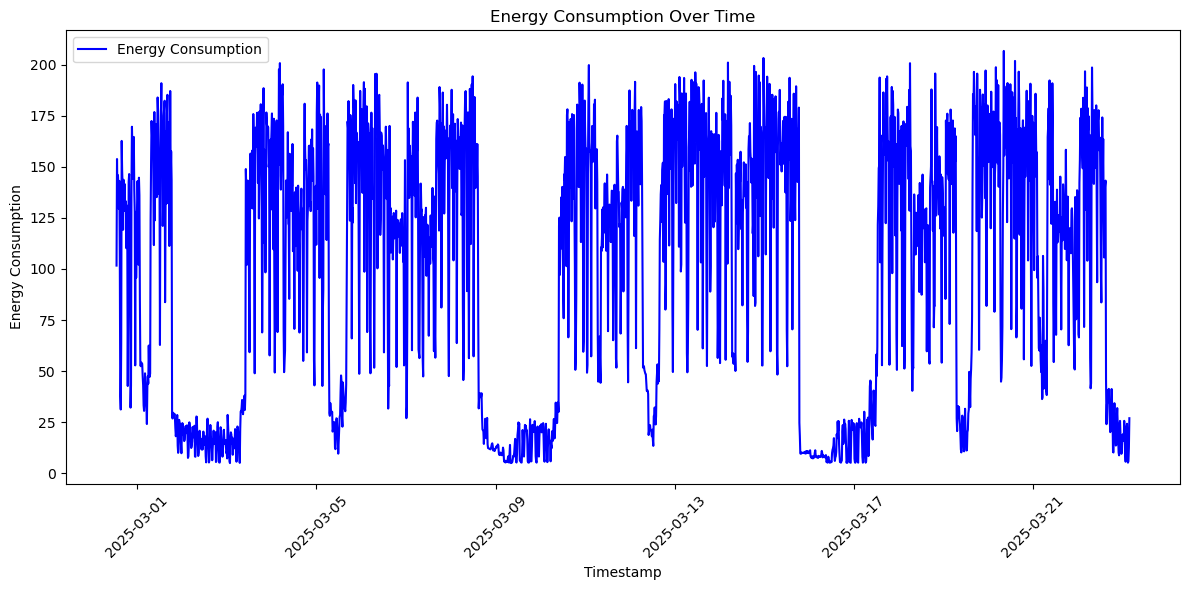

In [2]:
# plot the energy consumption
plt.figure(figsize=(12, 6))
plt.plot(ori_data['Timestamp'], ori_data['Energy'], label='Energy Consumption', color='blue')
plt.xlabel('Timestamp')
plt.ylabel('Energy Consumption')
plt.title('Energy Consumption Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('energy_consumption_plot.png', dpi=600, format='png')  # Save the energy consumption plot
# plt.show()

# Plot the heat map of original data based on day of week and hour

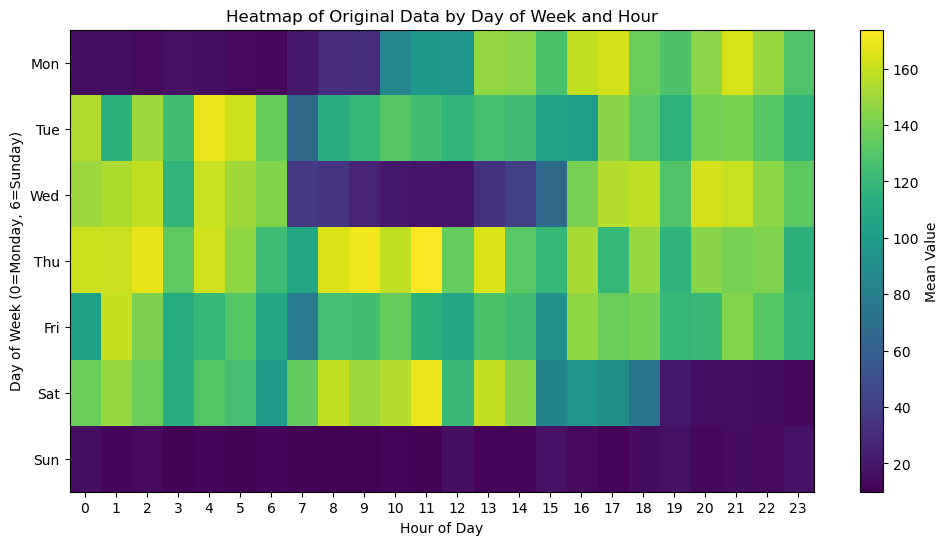

In [3]:
# Plot the heat map of original data based on day of week and hour and delete the newly added columns

def plot_heatmap(data):
    """
    Plot a heatmap of the original data based on day of week and hour.
    
    Args:
        data (pd.DataFrame): DataFrame containing the original data with 'Timestamp' column.
    """
    # Extract day of week and hour from the timestamp
    data['day_of_week'] = data['Timestamp'].dt.dayofweek
    data['hour'] = data['Timestamp'].dt.hour
    
    # Create a pivot table for the heatmap
    heatmap_data = data.pivot_table(index='day_of_week', columns='hour', values='Energy', aggfunc='mean')
    
    # Plot the heatmap
    plt.figure(figsize=(12, 6))
    plt.title('Heatmap of Original Data by Day of Week and Hour')
    plt.imshow(heatmap_data, cmap='viridis', aspect='auto')
    plt.colorbar(label='Mean Value')
    plt.xlabel('Hour of Day')
    plt.ylabel('Day of Week (0=Monday, 6=Sunday)')
    plt.xticks(ticks=np.arange(24), labels=np.arange(24))
    plt.yticks(ticks=np.arange(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    plt.show()
    
    # Drop the newly added columns
    data.drop(columns=['day_of_week', 'hour'], inplace=True)

plot_heatmap(ori_data)

# Plot the ACF (auto-correlation function) and PACF (partial auto-correlation function)

<Figure size 640x480 with 0 Axes>

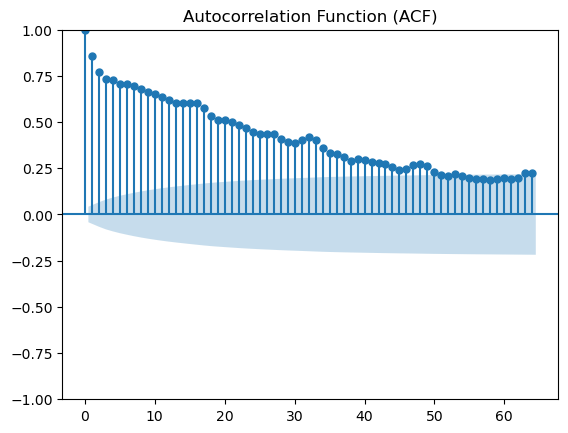

<Figure size 640x480 with 0 Axes>

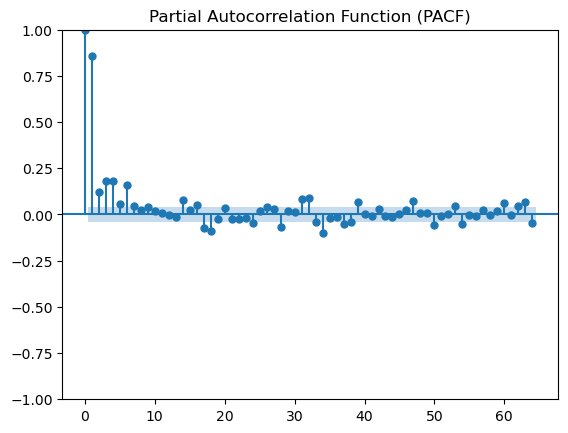

In [4]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


series = ori_data['Energy']

# 1) Autocorrelation Function
plt.figure()
plot_acf(series, lags=64)        # adjust lags as needed
plt.title('Autocorrelation Function (ACF)')
plt.show()

# 2) Partial Autocorrelation Function
plt.figure()
plot_pacf(series, lags=64, method='ywm')  # you can also try method='ld' or 'ywmle'
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()


In [5]:
def standard_scaler(data):

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    return scaled_data, scaler

def min_max_scaler(data):
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    return scaled_data, scaler

In [6]:
def XGBoost_model(X_train, Y_train, X_val, Y_val, X_test, Y_test, seed_val=42, pinball_loss_usage=False):
    """
    Trains XGBoost quantile regression models for 5%, 50%, 95% intervals.
    """

    quantiles = [0.05, 0.5, 0.95]
    models = {}
    predictions = {}
    X_test = X_test[48:-1]
    Y_test = Y_test[48:-1]
    if pinball_loss_usage:
        for q in quantiles:
            train_data = xgb.QuantileDMatrix(X_train, label=Y_train)
            val_data = xgb.QuantileDMatrix(X_val, label=Y_val)
            test_data = xgb.QuantileDMatrix(X_test, label=Y_test)

            params = {
                'objective': 'reg:quantileerror',
                'quantile_alpha': q,
                'eval_metric': 'mae',
                'learning_rate': 0.01,
                'max_depth': 5,
                'gamma': 1.0,
                'alpha': 0.1,
                'colsample_bytree': 0.8,
                'colsample_bynode': 0.8,
                'lambda': 0.1,
                'tree_method': 'hist',  # Required for QuantileDMatrix
                'seed': seed_val,
            }

            evals = [(train_data, 'train'), (val_data, 'eval')]
            model = xgb.train(params, train_data, num_boost_round=2000, early_stopping_rounds=100, evals=evals, verbose_eval=False)

            models[q] = model
            predictions[q] = model.predict(test_data)
        print("Shape of Y_test: ", Y_test.shape)
        return {
            'models': models,
            'predictions': predictions,
            'y_true': Y_test
        }
    else:
        train_data = xgb.DMatrix(X_train, label=Y_train)
        val_data = xgb.DMatrix(X_val, label=Y_val)
        test_data = xgb.DMatrix(X_test, label=Y_test)

        params = {
                'objective': 'reg:squarederror',
                # 'quantile_alpha': q,
                'eval_metric': 'rmse',
                'learning_rate': 0.01,
                'max_depth': 5,
                'gamma': 1.0,
                'alpha': 0.1,
                'colsample_bytree': 0.8,
                'colsample_bynode': 0.8,
                'lambda': 0.1,
                'tree_method': 'hist',  # Required for QuantileDMatrix
                'seed': seed_val,
            }

        evals = [(train_data, 'train'), (val_data, 'eval')]
        model = xgb.train(params, train_data, num_boost_round=1000, early_stopping_rounds=100, evals=evals, verbose_eval=False)
        predictions = model.predict(test_data)
        return predictions, model
def RF_model(X_train, Y_train, seed_val=42):
    from sklearn.ensemble import RandomForestRegressor
    
    model = RandomForestRegressor(n_estimators=100, random_state=seed_val)
    model.fit(X_train, Y_train)
    return model

def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q * e, (q - 1) * e))
    return loss

def BiLSTM_model(X_train, q, pinball_loss_usage=False):
        """Normalize all features to zero mean and unit variance (StandardScaler) after cutting your windows.


        Constructing the Bidirectional LSTM architecture.

        Returns:
            model (keras.model) : Returns the keras model.
        """
        # lr_schedule = ExponentialDecay(0.001, decay_steps=2500, decay_rate=0.96, staircase=True)
        model = Sequential()
        # model.add(Bidirectional(LSTM(50, activation='tanh', return_sequences=True, dropout= 0.1, recurrent_dropout= 0.2, input_shape=(X_train.shape[1], X_train.shape[2])), merge_mode='concat'))
        model.add(Bidirectional(LSTM(128, activation='tanh', return_sequences=True, dropout= 0.1, recurrent_dropout=0.2,input_shape=(X_train.shape[1], X_train.shape[2]))))
        # model.add(BatchNormalization())
        model.add(Dropout(0.1))
        model.add(Bidirectional(LSTM(128, activation='tanh', dropout= 0.1, recurrent_dropout=0.2, return_sequences=False)))
        # model.add(BatchNormalization())
        model.add(Dropout(0.1))
        model.add(Dense(1, activation='linear'))
        optimizer = Adam(learning_rate= 0.004)
        if pinball_loss_usage:
            model.compile(loss=quantile_loss(q), optimizer=optimizer, metrics=['mae', 'mape', 'mse'])
        else:
            model.compile(loss='mse', optimizer=optimizer, metrics=['mae', 'mape'])
        return model


def LSTM_model(X_train, q, pinball_loss_usage=False):
    # lr_schedule = ExponentialDecay(0.001, decay_steps=2500, decay_rate=0.96, staircase=True)
    model = Sequential()
    model.add(LSTM(128, activation= 'tanh', return_sequences=True, dropout= 0.1, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2])))
    # model.add(BatchNormalization())
    model.add(Dropout(0.2))
    model.add(LSTM(64, activation= 'tanh', recurrent_dropout=0.2, dropout= 0.1, return_sequences=False))
    # model.add(BatchNormalization())
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='linear'))
    # optimizer = Adam(learning_rate=lr_schedule)
    if pinball_loss_usage:
        model.compile(loss=quantile_loss(q), optimizer='Adam', metrics=['mae', 'mape', 'mse'])
    else:
        model.compile(loss='mse', optimizer='Adam', metrics=['mae', 'mape'])

    return model

/home/stelio/miniconda3/envs/tensorflow_gpu/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)


Mean Absolute Error (MAE): 107.47386518573062
Mean squared error (MSE): 16131.342956412958
Root Mean Squared Error (RMSE): 127.00922390288414
R² Score: -3.765483413511281
SMAPE score: 81.34269196145765


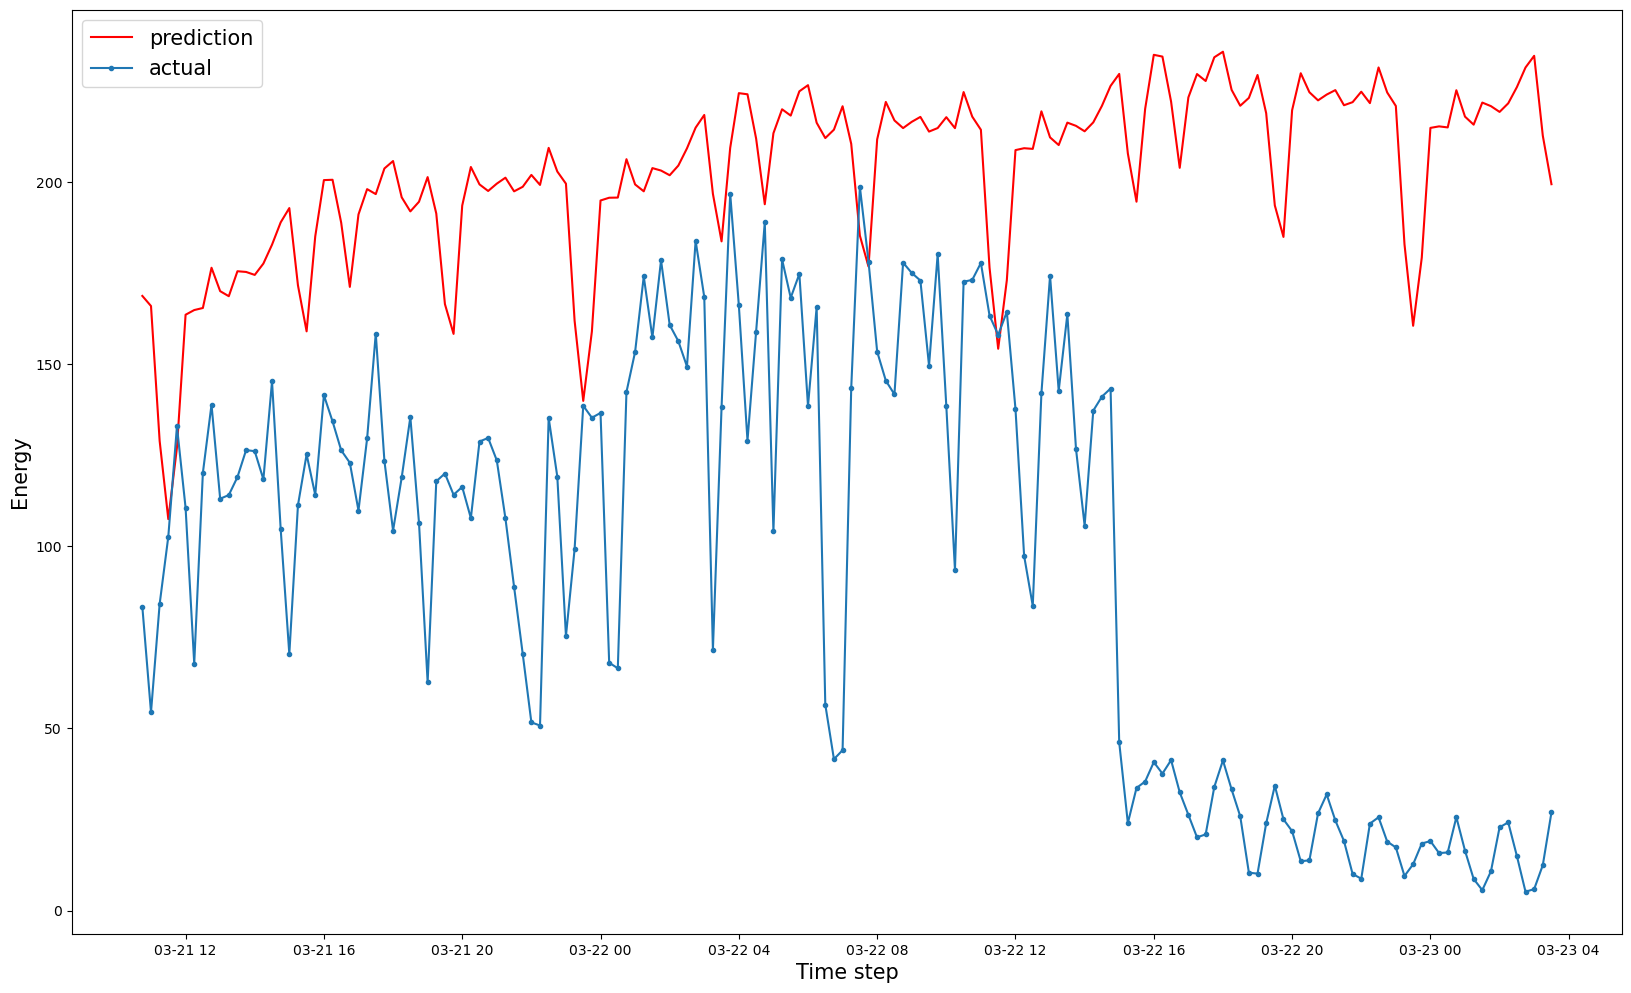

In [7]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# Baseline model
def Exp_Smoothing_model(train):
    """
    Constructing the Exponential Smoothing model.

    Returns:
        model (statsmodels.tsa.holtwinters.ExponentialSmoothing) : Returns the fitted model.
    """
    # Fit the model
    model = ExponentialSmoothing(train, trend='add', seasonal='add', damped_trend=True, seasonal_periods=48).fit()
    return model



# Baseline model
data = ori_data[['Timestamp','Energy']].copy()
# Ensure 'Timestamp' is the index
data.set_index('Timestamp', inplace=True)

series = data['Energy']
n = len(series)
train_end = int(n * 0.85)
val_end = train_end + int(n * 0.075)
train = series[:train_end]
val   = series[train_end:val_end]
test  = series[val_end:]
model = Exp_Smoothing_model(train)

forecast_steps = len(test)
forecast = model.forecast(forecast_steps)
forecast.index = test.index

shape2 = len(test)
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast)
n = len(test)
p = shape2
# MASE function
def mase(y_true, y_pred, y_naive):
    # y_true: Actual values
    # y_pred: Predicted values
    # y_naive: Naive model predictions (e.g., previous period's values)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_naive = np.asarray(y_naive)
    # Compute errors
    errors = np.abs(y_true - y_pred)
    
    # Calculate MAE of naive model
    naive_errors = np.abs(y_true[1:] - y_naive[1:])
    mae_naive = np.mean(naive_errors)
    
    # Calculate MASE
    mase_value = np.mean(errors) / mae_naive
    return mase_value
# SMAPE function
def smape(y_true, y_pred):
    # y_true: Actual values
    # y_pred: Predicted values
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    # Calculate SMAPE
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / denominator
    smape_value = 100 * np.mean(diff)
    return smape_value

smape_val = smape(test, forecast)
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean squared error (MSE): {mean_squared_error(test, forecast)}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R² Score: {r2}')
print(f"SMAPE score: {smape_val}")



plt.figure(figsize=(20,12))
plt.plot(forecast, label='prediction', color="r")
plt.plot(test, label='actual', marker='.')
plt.legend()
plt.ylabel('Energy', size=15)
plt.xlabel('Time step', size=15)
plt.legend(fontsize=15)
plt.show()

In [8]:
def training(seed_val = 42, model_type = 'BiLSTM', n_past = 48, batch_size = 32, scaler_name = 'min-max', data_augmentation = False, fake_data_length = 400, testing_stage = False, pinball_loss_usage = False):
    # Define seed for reproducibility
    os.environ["PYTHONHASHSEED"] = str(seed_val)
    random.seed(seed_val)
    np.random.seed(seed_val)
    tf.random.set_seed(seed_val)

    data = ori_data.copy()
    n_past = n_past # the ACF shows around 50 lags, so we can use 48 -> 12 hours of lookback
    n_future = 1

    data['Timestamp'] = pd.to_datetime(data['Timestamp'])

    # Window sliding technique used for Deep Learning models
    def split_sequence(X, Y, steps, out):
        Xs, Ys = list(), list()
        for i in range(len(X)):
            end = i + steps
            outi = end + out
            if outi > len(X)-1:
                break
            seqx, seqy = X[i:end], Y[end:outi]
            Xs.append(seqx)
            Ys.append(seqy)
        return np.array(Xs), np.array(Ys)
    
    # Add time features
    time_related_features = data[['Timestamp']].copy()      
    time_related_features['hour_sin'] = np.sin(2 * np.pi * time_related_features['Timestamp'].dt.hour / 24)
    time_related_features['hour_cos'] = np.cos(2 * np.pi * time_related_features['Timestamp'].dt.hour / 24)
    time_related_features['day_of_week_sin'] = np.sin(2 * np.pi * time_related_features['Timestamp'].dt.dayofweek / 7)
    time_related_features['day_of_week_cos'] = np.cos(2 * np.pi * time_related_features['Timestamp'].dt.dayofweek / 7)

    # Categorical features
    data.set_index('Timestamp', inplace=True)
    data['dow'] = data.index.day_name().str[:3]     # e.g. "Mon","Tue",…,"Sun"
    data['hour'] = data.index.hour # 0–23
    sun_low = data['dow'] == 'Sun' # basically all day on sunday
    mon_low = (data['dow'] == 'Mon') & data['hour'].isin([0,1,2,3,4,5,6,7,8,9]) # basically from 0 to 9 on monday
    wed_low = (data['dow'] == 'Wed') & data['hour'].isin([6,7,8,9,10,11,12,13,14]) # basically from 6 to 14 for maintenance on wednesday
    sat_low = (data['dow'] == 'Sat') & data['hour'].isin([19,20,21,22,23]) # basically from 19 to 23 on saturday
    data['is_low_usage'] = sun_low | mon_low | wed_low | sat_low
    data.drop(columns=['dow', 'hour'], inplace=True)
    data.reset_index(inplace=True)
    data['is_low_usage'] = data['is_low_usage'].astype(int)
    data['is_low_usage_next'] = data['is_low_usage'].shift(-1)
    
    X, Y, X_time= data.drop(columns=['Timestamp']), data['Energy'].values, time_related_features.drop(columns=['Timestamp'])
    X = pd.concat([X, X_time], axis=1)
    timestamps = data['Timestamp']
    X_train, X_val, Y_train, Y_val = train_test_split(X.values, Y, test_size=0.20, random_state=seed_val, shuffle=False)
    X_val, X_test, Y_val, Y_test = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)
    # Split validation data 5% and 5% in order to test in the start and then use the other 5% for the second phase after selection
    X_val1, X_val2, Y_val1, Y_val2 = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)

    # Create aligned timestamp splits
    timestamps_train, timestamps_val, _Y_train_dummy, _Y_val_dummy = train_test_split(
        timestamps, Y, test_size=0.20, random_state=seed_val, shuffle=False
    )
    timestamps_val, timestamps_test, _Y_val_dummy, _Y_test_dummy = train_test_split(
        timestamps_val, _Y_val_dummy, test_size=0.5, random_state=seed_val, shuffle=False
    )
    timestamps_val1, timestamps_val2, _Y_val1_dummy, _Y_val2_dummy = train_test_split(
        timestamps_val, _Y_val_dummy, test_size=0.5, random_state=seed_val, shuffle=False
    )
    
    # print(X_train.shape, type(X_train), X_val1.shape, type(X_val1))
    X_train, Y_train = split_sequence(X_train, Y_train, n_past, n_future)
    # X_val1, Y_val1 = split_sequence(X_val1, Y_val1, n_past, n_future)
    X_test, Y_test = split_sequence(X_test, Y_test, n_past, n_future)
    X_val1, Y_val1 = split_sequence(X_val1, Y_val1, n_past, n_future)
    X_val2, Y_val2 = split_sequence(X_val2, Y_val2, n_past, n_future)

  
    # train-test split
    # X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=seed_val, shuffle=False)
    # X_val, X_test, Y_val, Y_test = train_test_split(X_val, Y_val, test_size=0.75, random_state=seed_val, shuffle=False)

    #-----------Now the data is Train: 80%, Val_1: 5%, Val_2: 5%, Test: 10%----------------#

    if testing_stage:
        X_train = np.concatenate([X_train, X_val1], axis=0) # concatenate validation set to training set
        Y_train = np.concatenate([Y_train, Y_val1], axis=0)
        timestamps = timestamps_test  # concatenate timestamps for training set
        X_val = X_val2  # use the second validation set for validation
        Y_val = Y_val2  # use the second validation set for validation
    else:
        X_val = X_val1
        Y_val = Y_val1
        timestamps = timestamps_val1

    # separate the lagged values, numerical and time features, time features are the last 4 features in the X, lagged value features is the last before the time features
    X_numerical_train = X_train[:, :, :-7]    # all except last 7 (numerical features)
    X_lagged_train    = X_train[:, :, -7:-6]  # just the 7th-from-last (lagged feature)
    X_cat_train       = X_train[:, :, -6:-4]  # just the 6th-from-last (categorical feature)
    X_time_train      = X_train[:, :, -4:]    # last 4 are time features (time-related features)

    # VAL
    X_numerical_val = X_val[:, :, :-7]
    X_lagged_val    = X_val[:, :, -7:-6]
    X_cat_val       = X_val[:, :, -6:-4]
    X_time_val      = X_val[:, :, -4:]

    # TEST
    X_numerical_test = X_test[:, :, :-7]
    X_lagged_test    = X_test[:, :, -7:-6]
    X_cat_test       = X_test[:, :, -6:-4]
    X_time_test      = X_test[:, :, -4:]


    # broadcast ONLY is_low_usage_next across timesteps, in order to use it as a feature (low_usage from t+1 timestep) and because keep a constant value through the sequence
    # TRAIN
    X_cat_train[:, :, 1] = X_cat_train[:, -1, 1][:, None]
    # VAL
    X_cat_val[:,   :, 1] = X_cat_val[:,   -1, 1][:, None]
    # TEST
    X_cat_test[:,  :, 1] = X_cat_test[:,  -1, 1][:, None]


    if data_augmentation:
        fake_data = np.load("PANDORA_HALCOR_ddpm_fake_energy_raw.npy")
        num_original = X_train.shape[0]
        fake_ratio = fake_data_length
        num_fake = int(num_original * fake_ratio)
        fake_data = fake_data[:num_fake]
        _, seq_len, F = fake_data.shape
        X_fake = fake_data[:, :seq_len-1, :]
        Y_fake = fake_data[:, seq_len-1, F-1]
        Y_fake = Y_fake.reshape(-1, 1)
        X_fake_numerical_train = X_fake[:, :, :-7] 
        X_fake_cat_train= X_fake[:, :, -7:-5] 
        X_fake_lagged_train = X_fake[:, :, -1:] 
        X_fake_time_train = X_fake[:, :, -5:-1] 

    if scaler_name == 'min-max':

        N, seq_len, F = X_numerical_train.shape
        X_numerical_train, scaler = min_max_scaler(X_numerical_train.reshape(-1, X_numerical_train.shape[-1]))
        X_numerical_train = X_numerical_train.reshape(N, seq_len, F)
        X_numerical_val = scaler.transform(X_numerical_val.reshape(-1, X_numerical_val.shape[-1]))
        X_numerical_val = X_numerical_val.reshape(X_val.shape[0], seq_len, F)
        X_numerical_test = scaler.transform(X_numerical_test.reshape(-1, X_numerical_test.shape[-1]))
        X_numerical_test = X_numerical_test.reshape(X_test.shape[0], seq_len, F)
            
        Y_train, scaler_target = min_max_scaler(Y_train)
        Y_val = scaler_target.transform(Y_val)
        Y_test = scaler_target.transform(Y_test)
        X_lagged_train = scaler_target.transform(X_lagged_train.reshape(-1, X_lagged_train.shape[-1]))
        X_lagged_train = X_lagged_train.reshape(N, seq_len, 1)
        X_lagged_val = scaler_target.transform(X_lagged_val.reshape(-1, X_lagged_val.shape[-1]))
        X_lagged_val = X_lagged_val.reshape(X_val.shape[0], seq_len, 1)
        X_lagged_test = scaler_target.transform(X_lagged_test.reshape(-1, X_lagged_test.shape[-1]))
        X_lagged_test = X_lagged_test.reshape(X_test.shape[0], seq_len, 1)


        #fake data augmentation
        if data_augmentation:
            N, seq_len, F = X_fake_numerical_train.shape

            X_fake_numerical_train = scaler.transform(X_fake_numerical_train.reshape(-1, X_fake_numerical_train.shape[-1]))
            X_fake_numerical_train = X_fake_numerical_train.reshape(N, seq_len, F)
            X_fake_lagged_train = scaler_target.transform(X_fake_lagged_train.reshape(-1, X_fake_lagged_train.shape[-1]))
            X_fake_lagged_train = X_fake_lagged_train.reshape(N, seq_len, 1)
            Y_fake = scaler_target.transform(Y_fake)

    elif scaler_name == 'standard':

        N, seq_len, F = X_numerical_train.shape
        X_numerical_train, scaler = standard_scaler(X_numerical_train.reshape(-1, X_numerical_train.shape[-1]))
        X_numerical_train = X_numerical_train.reshape(N, seq_len, F)
        X_numerical_val = scaler.transform(X_numerical_val.reshape(-1, X_numerical_val.shape[-1]))
        X_numerical_val = X_numerical_val.reshape(X_val.shape[0], seq_len, F)
        X_numerical_test = scaler.transform(X_numerical_test.reshape(-1, X_numerical_test.shape[-1]))
        X_numerical_test = X_numerical_test.reshape(X_test.shape[0], seq_len, F)

        Y_train, scaler_target = standard_scaler(Y_train)
        Y_val = scaler_target.transform(Y_val)
        Y_test = scaler_target.transform(Y_test)
        X_lagged_train = scaler_target.transform(X_lagged_train.reshape(-1, X_lagged_train.shape[-1]))
        X_lagged_train = X_lagged_train.reshape(N, seq_len, 1)
        X_lagged_val = scaler_target.transform(X_lagged_val.reshape(-1, X_lagged_val.shape[-1]))
        X_lagged_val = X_lagged_val.reshape(X_val.shape[0], seq_len, 1)
        X_lagged_test = scaler_target.transform(X_lagged_test.reshape(-1, X_lagged_test.shape[-1]))
        X_lagged_test = X_lagged_test.reshape(X_test.shape[0], seq_len, 1)


        #fake data augmentation
        if data_augmentation:
            N, seq_len, F = X_fake_numerical_train.shape

            X_fake_numerical_train = scaler.transform(X_fake_numerical_train.reshape(-1, X_fake_numerical_train.shape[-1]))
            X_fake_numerical_train = X_fake_numerical_train.reshape(N, seq_len, F)
            X_fake_lagged_train = scaler_target.transform(X_fake_lagged_train.reshape(-1, X_fake_lagged_train.shape[-1]))
            X_fake_lagged_train = X_fake_lagged_train.reshape(N, seq_len, 1)
            Y_fake = scaler_target.transform(Y_fake)

    X_train = np.concatenate([X_numerical_train, X_cat_train, X_time_train, X_lagged_train], axis=2)    
    X_val = np.concatenate([X_numerical_val, X_cat_val, X_time_val, X_lagged_val], axis=2)
    X_test = np.concatenate([X_numerical_test, X_cat_test, X_time_test, X_lagged_test], axis=2)
    # X_train = X_numerical_train
    # X_val = X_numerical_val
    # X_test = X_numerical_test

    if data_augmentation:
        X_fake = np.concatenate([X_fake_numerical_train, X_fake_cat_train, X_fake_time_train, X_fake_lagged_train], axis=2)
        X_train, Y_train = np.concatenate([X_train, X_fake], axis=0), np.concatenate([Y_train, Y_fake], axis=0)


    print("Size of training data is: ", X_train.shape)
    quantiles = [0.05, 0.5, 0.95]
    models = {}
    histories = {}

    early_stop = EarlyStopping(
                monitor='val_loss',     # or 'val_mae' depending on preference
                patience=15,             # stop after 15 epochs with no improvement
                restore_best_weights=True # rollback to the best model weights
    )
    if pinball_loss_usage:
        for q in quantiles:
            print(f"Training {model_type} for quantile {q}...")

            if model_type == 'BiLSTM':
                model = BiLSTM_model(X_train, q, pinball_loss_usage)
            elif model_type == 'LSTM':
                model = LSTM_model(X_train, q, pinball_loss_usage)

            history = model.fit(X_train, Y_train, validation_data = (X_val, Y_val), epochs=500, batch_size=batch_size, verbose=1, shuffle=True, callbacks=[early_stop, WandbMetricsLogger()])
            models[q] = model
            histories[q] = history
    else:
        print(f"Training {model_type}...")

        if model_type == 'BiLSTM':
            model = BiLSTM_model(X_train, 0, pinball_loss_usage)
        elif model_type == 'LSTM':
            model = LSTM_model(X_train, 0, pinball_loss_usage)
        
        model.fit(X_train, Y_train, validation_data = (X_val, Y_val), epochs=500, batch_size=batch_size, verbose=1, shuffle=True, callbacks=[early_stop, WandbMetricsLogger()])
        
    # print(X_val.shape)
    predictions = {}
    if pinball_loss_usage:
        if testing_stage:
            for q in quantiles:
                predictions[q] = models[q].predict(X_test)
        else:
            for q in quantiles:
                predictions[q] = models[q].predict(X_val)
    else:
        if testing_stage:
            predictions = model.predict(X_test)
        else:
            predictions = model.predict(X_val)

    # print(X_val.shape)

    if pinball_loss_usage:
        y_pred_q05 = predictions[0.05]
        y_pred_q50 = predictions[0.5]
        y_pred_q95 = predictions[0.95]

        predictions = scaler_target.inverse_transform(y_pred_q50.reshape(-1, 1))
        y_pred_q05 = scaler_target.inverse_transform(y_pred_q05.reshape(-1, 1))
        y_pred_q95 = scaler_target.inverse_transform(y_pred_q95.reshape(-1, 1))
    else:
        predictions = scaler_target.inverse_transform(predictions.reshape(-1, 1))
        
    # predictions = model.predict(X_val)
    if not testing_stage:
        Y_test = Y_val

    Y_test = scaler_target.inverse_transform(Y_test)


    # Save predictions to a local file
    filename = f"model_name_{model_type}_predictions_seed_{seed_val}_augmentation_{batch_size}_scaler_{scaler_name}_DA_{data_augmentation}_pinball_{pinball_loss_usage}.npz"
    np.savez(filename, predictions=predictions.flatten(), ground_truth=Y_test.flatten())

    # Create an artifact
    artifact = wandb.Artifact(
        name=f"model_name_{model_type}_predictions_seed_{seed_val}_augmentation_{batch_size}_scaler_{scaler_name}_DA_{data_augmentation}_pinball_{pinball_loss_usage}",
        type="predictions",
        description="Predictions and ground truth for one run",
        metadata={
            "seed": seed_val,
            "model": model_type,
            "scaler": scaler_name,
            "batch_size": batch_size,
            "data_aug": data_augmentation,
            "fake_data_len": fake_data_length
        }
    )

    # Add file and log it
    artifact.add_file(filename)
    wandb.log_artifact(artifact)

    # Optional: Clean up local file
    # os.remove(filename)
    


    #------------QUANTILE METRICS-----------------#
    if pinball_loss_usage:
    # Pinball loss for quantiles
        def pinball_loss(y_true, y_pred, q):
            """
            Pinball loss for quantile q.
            y_true, y_pred must be arrays of same shape.
            """
            e = y_true - y_pred
            return np.mean(np.maximum(q*e, (q-1)*e))
        
        loss_q05 = pinball_loss(Y_test, y_pred_q05, 0.05)
        loss_q50 = pinball_loss(Y_test, y_pred_q50, 0.5)
        loss_q95 = pinball_loss(Y_test, y_pred_q95, 0.95)

        # Coverage (Calibration of prediction intervals)
        def interval_coverage(y_true, y_lower, y_upper, nominal=0.90):
            """
            Computes empirical coverage of [y_lower, y_upper].
            """
            inside = (y_true >= y_lower) & (y_true <= y_upper)
            empirical = np.mean(inside)
            return empirical, empirical - nominal
        
        coverage_90, error_90 = interval_coverage(Y_test, y_pred_q05, y_pred_q95, nominal=0.90)


        # Interval Width (Sharpness)
        def interval_width(y_lower, y_upper):
            return np.mean(y_upper - y_lower)
        

        sharpness_90 = interval_width(y_pred_q05, y_pred_q95)


        wandb.log({
        "Pinball_0.05": loss_q05,
        "Pinball_0.50": loss_q50,
        "Pinball_0.95": loss_q95,
        "Coverage_0.90": coverage_90,
        "Coverage_Error_0.90": error_90,
        "Sharpness_0.90": sharpness_90
        })

    #------------QUANTILE METRICS END-----------------#

    #------------Point forecast metrics-----------------#
    mae = mean_absolute_error(Y_test, predictions)
    rmse = np.sqrt(mean_squared_error(Y_test, predictions))
    r2 = r2_score(Y_test, predictions)
    n = len(Y_test)
    # p = shape2
    # MASE function
    def mase(y_true, y_pred, y_naive):
        # y_true: Actual values
        # y_pred: Predicted values
        # y_naive: Naive model predictions (e.g., previous period's values)
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        y_naive = np.asarray(y_naive)
        # Compute errors
        errors = np.abs(y_true - y_pred)
        
        # Calculate MAE of naive model
        naive_errors = np.abs(y_true[1:] - y_naive[1:])
        mae_naive = np.mean(naive_errors)
        
        # Calculate MASE
        mase_value = np.mean(errors) / mae_naive
        return mase_value
    # SMAPE function
    def smape(y_true, y_pred):
        # y_true: Actual values
        # y_pred: Predicted values
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        # Calculate SMAPE
        denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
        diff = np.abs(y_true - y_pred) / denominator
        smape_value = 100 * np.mean(diff)
        return smape_value
    smape_val = smape(Y_test, predictions)
    y_naive = np.roll(Y_test, 1)
    mase_val = mase(Y_test, predictions, y_naive)
    print(f'Mean Absolute Error (MAE): {mae}')
    print(f'Mean squared error (MSE): {mean_squared_error(Y_test, predictions)}')
    print(f'Root Mean Squared Error (RMSE): {rmse}')
    print(f'R² Score: {r2}')
    print(f"SMAPE score: {smape_val}")
    print(f"MASE score: {mase_val}")

    print(predictions.shape, Y_test.shape)
    if pinball_loss_usage:
        # pinball loss plot
        timestamps = timestamps[48:-1]
        print(timestamps.shape)
        plt.figure(figsize=(14, 6))
        plt.plot(timestamps, Y_test.squeeze(), label="Ground Truth", color='black', linewidth=2)
        plt.plot(timestamps, predictions.squeeze(), label="Median Prediction (0.5)", color='#0072B2', linewidth=2)
        plt.fill_between(
            timestamps, y_pred_q05.squeeze(), y_pred_q95.squeeze(),
            color='#0072B2', alpha=0.2, label="90% Confidence Interval (0.05–0.95)"
        )

        # Custom x-axis formatter → weekday + month-day + hour:00
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %m-%d %H:%M'))

        plt.grid(alpha=0.3)
        plt.title(f"{model_type} Quantile Regression - Confidence Interval")
        plt.xlabel("Time")
        plt.ylabel("Energy")
        plt.legend(fontsize=12)
        plt.tight_layout()
        wandb.log({"train vs val_predictions": wandb.Image(plt)})
        plt.close()
    else: # mse loss plot
        timestamps = timestamps[48:-1]
        print(timestamps.shape)
        plt.figure(figsize=(14, 6))
        plt.plot(timestamps, Y_test.squeeze(), label="Ground Truth", color='black', linewidth=2)
        plt.plot(timestamps, predictions.squeeze(), label="Prediction", color='#0072B2', linewidth=2)

        # Custom x-axis formatter → weekday + month-day + hour:00
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %m-%d %H:%M'))

        plt.grid(alpha=0.3)
        plt.title(f"{model_type} - MSE Regression")
        plt.xlabel("Time")
        plt.ylabel("Energy")
        plt.legend(fontsize=12)
        plt.tight_layout()
        wandb.log({"train vs val_predictions": wandb.Image(plt)})
        plt.close()

    wandb.log({
    "val_MAE": mae,
    "val_MSE": mean_squared_error(Y_test, predictions),
    "val_RMSE": rmse,
    "val_R2": r2,
    "val_SMAPE": smape_val,
    "val_MASE": mase_val
    })

sweep_config = {
    'method': 'grid',
    'parameters': {
        'model_name': {
            'values': ['LSTM', 'BiLSTM']
            # 'values': ['BiLSTM', 'LSTM']
        },
        'scaler_name': {
            'values': ['standard']
            
            # 'values': ['standard', 'min-max']
        },
        'batch_size': {
            'values': [32, 16]
            # 'values': [32]
        },
        'data_augmentation': {
            'values': [True]
        },
        'seed': {
            'values': [42, 4242, 777, 2021, 1234]
            # 'values' : [2021, 1234, 777]
        },
        'fake_data_length': {
            # 'values': [200, 400, 800, 1200, 1600]
            'values': [0.1, 0.25, 0.5, 0.75, 1.0]
        },
        'pinball_loss_usage': {
            'values': [False]
        },
        'testing_stage': {
            'values': [True]
        }
    }
}

project_base = f"PANDORA-HALCOR-ENERGY-TIMESERIES-FORECASTING-MSE-TESTING"
sweep_id = wandb.sweep(sweep=sweep_config, project=project_base)


def sweep_train():
    run = wandb.init()

    # Extract config values
    model = run.config.model_name
    scaler = run.config.scaler_name
    batch_size = run.config.batch_size

    run.name = f"{model}-{scaler}-bs{batch_size}-aug{run.config.data_augmentation}--seed{run.config.seed}--fake_data_length{run.config.fake_data_length}---pinball_loss_usage{run.config.pinball_loss_usage}---testing_stage{run.config.testing_stage}"

    # Run your training pipeline
    training(
        seed_val=run.config.seed,
        model_type=model,
        batch_size=batch_size,
        scaler_name=scaler,
        data_augmentation=run.config.data_augmentation,
        fake_data_length=run.config.fake_data_length,
        testing_stage=run.config.testing_stage,
        pinball_loss_usage=run.config.pinball_loss_usage
    )

wandb.agent(sweep_id, function=sweep_train)

Create sweep with ID: zxgtfzub
Sweep URL: https://wandb.ai/synthetic-data-gan/PANDORA-HALCOR-ENERGY-TIMESERIES-FORECASTING-MSE-TESTING/sweeps/zxgtfzub


wandb: Agent Starting Run: cbuaqmpa with config:
wandb: 	batch_size: 32
wandb: 	data_augmentation: True
wandb: 	fake_data_length: 0.1
wandb: 	model_name: LSTM
wandb: 	pinball_loss_usage: False
wandb: 	scaler_name: standard
wandb: 	seed: 42
wandb: 	testing_stage: True
wandb: Currently logged in as: steliobompai (synthetic-data-gan) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Size of training data is:  (1920, 48, 18)
Training LSTM...


I0000 00:00:1760639096.243824  440990 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1760639096.278824  440990 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1760639096.279087  440990 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1760639096.280742  440990 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Epoch 1/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.3932 - mae: 0.4930 - mape: 103.2184 - val_loss: 0.4182 - val_mae: 0.5658 - val_mape: 77.2250
Epoch 2/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.2254 - mae: 0.3532 - mape: 102.2424 - val_loss: 0.3181 - val_mae: 0.4633 - val_mape: 72.2337
Epoch 3/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.1960 - mae: 0.3320 - mape: 88.2423 - val_loss: 0.2823 - val_mae: 0.4529 - val_mape: 65.4010
Epoch 4/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.1805 - mae: 0.3118 - mape: 86.4141 - val_loss: 0.2239 - val_mae: 0.4009 - val_mape: 57.3864
Epoch 5/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1462 - mae: 0.2827 - mape: 71.9720 - val_loss: 0.1525 - val_mae: 0.3104 - val_mape: 45.5620
Epoch 6/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1334 - mae: 0.2745 - mape: 73.7148 - val_loss: 0.1446 - val_mae: 0.2999 - val_mape: 41.8538
Epoch 7/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.1242 - mae: 

...

Size of training data is:  (3492, 48, 18)
Training BiLSTM...
Epoch 1/500


/home/stelio/miniconda3/envs/tensorflow_gpu/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 86ms/step - loss: 0.2620 - mae: 0.3723 - mape: 76.5267 - val_loss: 0.1775 - val_mae: 0.3501 - val_mape: 43.0250
Epoch 2/500
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - loss: 0.0702 - mae: 0.2003 - mape: 46.4308 - val_loss: 0.0964 - val_mae: 0.2480 - val_mape: 38.7308
Epoch 3/500
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - loss: 0.0590 - mae: 0.1818 - mape: 42.8634 - val_loss: 0.1051 - val_mae: 0.2608 - val_mape: 37.3663
Epoch 4/500
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - loss: 0.0489 - mae: 0.1656 - mape: 38.4239 - val_loss: 0.1043 - val_mae: 0.2555 - val_mape: 36.7148
Epoch 5/500
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - loss: 0.0454 - mae: 0.1588 - mape: 39.6925 - val_loss: 0.0887 - val_mae: 0.2313 - val_mape: 34.9446
Epoch 6/500
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - loss: 0.0476 - mae: 0.1629 - mape: 37.7245 - val_loss: 0.0814 - val_mae: 0.2199 - val_mape: 32.4406
Epoch 7/500
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - loss: 0.0420 

epoch/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/mae,█▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/mape,█▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_loss,█▃▃▃▂▃▃▂▂▂▃▃▂▂▃▂▁▂▁▃▂▂▃▂▁▂▂▁▁▁▂▂▁▁▂▂▁▂▂▂
epoch/val_mae,█▃▄▄▃▃▃▂▃▃▃▃▂▂▂▂▁▃▂▃▃▂▂▂▁▁▁▁▃▃▁▁▁▁▂▂▂▂▂▃
epoch/val_mape,█▅▅▄▃▃▃▂▃▃▄▅▃▃▂▂▁▁▃▁▃▅▃▂▃▁▂▂▃▄▄▃▃▂▂▂▃▂▃▂
val_MAE,▁
val_MASE,▁
val_MSE,▁


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


In [ ]:
def training(seed_val = 42, model_type = 'BiLSTM', n_past = 48, batch_size = 32, scaler_name = 'min-max', data_augmentation = False, fake_data_length = 400, testing_stage = False, pinball_loss_usage = False):
    # Define seed for reproducibility
    os.environ["PYTHONHASHSEED"] = str(seed_val)
    random.seed(seed_val)
    np.random.seed(seed_val)
    tf.random.set_seed(seed_val)

    data = ori_data.copy()
    n_past = n_past # the ACF shows around 50 lags, so we can use 48 -> 12 hours of lookback
    n_future = 1

    data['Timestamp'] = pd.to_datetime(data['Timestamp'])

    # Window sliding technique used for Deep Learning models
    def split_sequence(X, Y, steps, out):
        Xs, Ys = list(), list()
        for i in range(len(X)):
            end = i + steps
            outi = end + out
            if outi > len(X)-1:
                break
            seqx, seqy = X[i:end], Y[end:outi]
            Xs.append(seqx)
            Ys.append(seqy)
        return np.array(Xs), np.array(Ys)
    
    # Add time features
    time_related_features = data[['Timestamp']].copy()      
    time_related_features['hour_sin'] = np.sin(2 * np.pi * time_related_features['Timestamp'].dt.hour / 24)
    time_related_features['hour_cos'] = np.cos(2 * np.pi * time_related_features['Timestamp'].dt.hour / 24)
    time_related_features['day_of_week_sin'] = np.sin(2 * np.pi * time_related_features['Timestamp'].dt.dayofweek / 7)
    time_related_features['day_of_week_cos'] = np.cos(2 * np.pi * time_related_features['Timestamp'].dt.dayofweek / 7)

    # Categorical features
    data.set_index('Timestamp', inplace=True)
    data['dow'] = data.index.day_name().str[:3]     # e.g. "Mon","Tue",…,"Sun"
    data['hour'] = data.index.hour # 0–23
    sun_low = data['dow'] == 'Sun' # basically all day on sunday
    mon_low = (data['dow'] == 'Mon') & data['hour'].isin([0,1,2,3,4,5,6,7,8,9]) # basically from 0 to 9 on monday
    wed_low = (data['dow'] == 'Wed') & data['hour'].isin([6,7,8,9,10,11,12,13,14]) # basically from 6 to 14 for maintenance on wednesday
    sat_low = (data['dow'] == 'Sat') & data['hour'].isin([19,20,21,22,23]) # basically from 19 to 23 on saturday
    data['is_low_usage'] = sun_low | mon_low | wed_low | sat_low
    data.drop(columns=['dow', 'hour'], inplace=True)
    data.reset_index(inplace=True)
    data['is_low_usage'] = data['is_low_usage'].astype(int)
    data['is_low_usage_next'] = data['is_low_usage'].shift(-1)
    
    X, Y, X_time= data.drop(columns=['Timestamp']), data['Energy'].values, time_related_features.drop(columns=['Timestamp'])
    X = pd.concat([X, X_time], axis=1)
    timestamps = data['Timestamp']
    X_train, X_val, Y_train, Y_val = train_test_split(X.values, Y, test_size=0.20, random_state=seed_val, shuffle=False)
    X_val, X_test, Y_val, Y_test = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)
    # Split validation data 5% and 5% in order to test in the start and then use the other 5% for the second phase after selection
    X_val1, X_val2, Y_val1, Y_val2 = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)

    # Create aligned timestamp splits
    timestamps_train, timestamps_val, _Y_train_dummy, _Y_val_dummy = train_test_split(
        timestamps, Y, test_size=0.20, random_state=seed_val, shuffle=False
    )
    timestamps_val, timestamps_test, _Y_val_dummy, _Y_test_dummy = train_test_split(
        timestamps_val, _Y_val_dummy, test_size=0.5, random_state=seed_val, shuffle=False
    )
    timestamps_val1, timestamps_val2, _Y_val1_dummy, _Y_val2_dummy = train_test_split(
        timestamps_val, _Y_val_dummy, test_size=0.5, random_state=seed_val, shuffle=False
    )
    
    # print(X_train.shape, type(X_train), X_val1.shape, type(X_val1))
    X_train, Y_train = split_sequence(X_train, Y_train, n_past, n_future)
    # X_val1, Y_val1 = split_sequence(X_val1, Y_val1, n_past, n_future)
    X_test, Y_test = split_sequence(X_test, Y_test, n_past, n_future)
    X_val1, Y_val1 = split_sequence(X_val1, Y_val1, n_past, n_future)
    X_val2, Y_val2 = split_sequence(X_val2, Y_val2, n_past, n_future)

  
    # train-test split
    # X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=seed_val, shuffle=False)
    # X_val, X_test, Y_val, Y_test = train_test_split(X_val, Y_val, test_size=0.75, random_state=seed_val, shuffle=False)

    #-----------Now the data is Train: 80%, Val_1: 5%, Val_2: 5%, Test: 10%----------------#

    if testing_stage:
        X_train = np.concatenate([X_train, X_val1], axis=0) # concatenate validation set to training set
        Y_train = np.concatenate([Y_train, Y_val1], axis=0)
        timestamps = timestamps_test  # concatenate timestamps for training set
        X_val = X_val2  # use the second validation set for validation
        Y_val = Y_val2  # use the second validation set for validation
    else:
        X_val = X_val1
        Y_val = Y_val1
        timestamps = timestamps_val1

    # separate the lagged values, numerical and time features, time features are the last 4 features in the X, lagged value features is the last before the time features
    X_numerical_train = X_train[:, :, :-7]    # all except last 7 (numerical features)
    X_lagged_train    = X_train[:, :, -7:-6]  # just the 7th-from-last (lagged feature)
    X_cat_train       = X_train[:, :, -6:-4]  # just the 6th-from-last (categorical feature)
    X_time_train      = X_train[:, :, -4:]    # last 4 are time features (time-related features)

    # VAL
    X_numerical_val = X_val[:, :, :-7]
    X_lagged_val    = X_val[:, :, -7:-6]
    X_cat_val       = X_val[:, :, -6:-4]
    X_time_val      = X_val[:, :, -4:]

    # TEST
    X_numerical_test = X_test[:, :, :-7]
    X_lagged_test    = X_test[:, :, -7:-6]
    X_cat_test       = X_test[:, :, -6:-4]
    X_time_test      = X_test[:, :, -4:]


    # broadcast ONLY is_low_usage_next across timesteps, in order to use it as a feature (low_usage from t+1 timestep) and because keep a constant value through the sequence
    # TRAIN
    X_cat_train[:, :, 1] = X_cat_train[:, -1, 1][:, None]
    # VAL
    X_cat_val[:,   :, 1] = X_cat_val[:,   -1, 1][:, None]
    # TEST
    X_cat_test[:,  :, 1] = X_cat_test[:,  -1, 1][:, None]


    if data_augmentation:
        fake_data = np.load("ddpm_fake_energy_raw.npy")
        fake_data = fake_data[:fake_data_length]
        _, seq_len, F = fake_data.shape
        X_fake = fake_data[:, :seq_len-1, :]
        Y_fake = fake_data[:, seq_len-1, F-1]
        Y_fake = Y_fake.reshape(-1, 1)
        X_fake_numerical_train = X_fake[:, :, :-7] 
        X_fake_cat_train= X_fake[:, :, -7:-5] 
        X_fake_lagged_train = X_fake[:, :, -1:] 
        X_fake_time_train = X_fake[:, :, -5:-1] 

    if scaler_name == 'min-max':

        N, seq_len, F = X_numerical_train.shape
        X_numerical_train, scaler = min_max_scaler(X_numerical_train.reshape(-1, X_numerical_train.shape[-1]))
        X_numerical_train = X_numerical_train.reshape(N, seq_len, F)
        X_numerical_val = scaler.transform(X_numerical_val.reshape(-1, X_numerical_val.shape[-1]))
        X_numerical_val = X_numerical_val.reshape(X_val.shape[0], seq_len, F)
        X_numerical_test = scaler.transform(X_numerical_test.reshape(-1, X_numerical_test.shape[-1]))
        X_numerical_test = X_numerical_test.reshape(X_test.shape[0], seq_len, F)
            
        Y_train, scaler_target = min_max_scaler(Y_train)
        Y_val = scaler_target.transform(Y_val)
        Y_test = scaler_target.transform(Y_test)
        X_lagged_train = scaler_target.transform(X_lagged_train.reshape(-1, X_lagged_train.shape[-1]))
        X_lagged_train = X_lagged_train.reshape(N, seq_len, 1)
        X_lagged_val = scaler_target.transform(X_lagged_val.reshape(-1, X_lagged_val.shape[-1]))
        X_lagged_val = X_lagged_val.reshape(X_val.shape[0], seq_len, 1)
        X_lagged_test = scaler_target.transform(X_lagged_test.reshape(-1, X_lagged_test.shape[-1]))
        X_lagged_test = X_lagged_test.reshape(X_test.shape[0], seq_len, 1)


        #fake data augmentation
        if data_augmentation:
            N, seq_len, F = X_fake_numerical_train.shape

            X_fake_numerical_train = scaler.transform(X_fake_numerical_train.reshape(-1, X_fake_numerical_train.shape[-1]))
            X_fake_numerical_train = X_fake_numerical_train.reshape(N, seq_len, F)
            X_fake_lagged_train = scaler_target.transform(X_fake_lagged_train.reshape(-1, X_fake_lagged_train.shape[-1]))
            X_fake_lagged_train = X_fake_lagged_train.reshape(N, seq_len, 1)
            Y_fake = scaler_target.transform(Y_fake)

    elif scaler_name == 'standard':

        N, seq_len, F = X_numerical_train.shape
        X_numerical_train, scaler = standard_scaler(X_numerical_train.reshape(-1, X_numerical_train.shape[-1]))
        X_numerical_train = X_numerical_train.reshape(N, seq_len, F)
        X_numerical_val = scaler.transform(X_numerical_val.reshape(-1, X_numerical_val.shape[-1]))
        X_numerical_val = X_numerical_val.reshape(X_val.shape[0], seq_len, F)
        X_numerical_test = scaler.transform(X_numerical_test.reshape(-1, X_numerical_test.shape[-1]))
        X_numerical_test = X_numerical_test.reshape(X_test.shape[0], seq_len, F)

        Y_train, scaler_target = standard_scaler(Y_train)
        Y_val = scaler_target.transform(Y_val)
        Y_test = scaler_target.transform(Y_test)
        X_lagged_train = scaler_target.transform(X_lagged_train.reshape(-1, X_lagged_train.shape[-1]))
        X_lagged_train = X_lagged_train.reshape(N, seq_len, 1)
        X_lagged_val = scaler_target.transform(X_lagged_val.reshape(-1, X_lagged_val.shape[-1]))
        X_lagged_val = X_lagged_val.reshape(X_val.shape[0], seq_len, 1)
        X_lagged_test = scaler_target.transform(X_lagged_test.reshape(-1, X_lagged_test.shape[-1]))
        X_lagged_test = X_lagged_test.reshape(X_test.shape[0], seq_len, 1)


        #fake data augmentation
        if data_augmentation:
            N, seq_len, F = X_fake_numerical_train.shape

            X_fake_numerical_train = scaler.transform(X_fake_numerical_train.reshape(-1, X_fake_numerical_train.shape[-1]))
            X_fake_numerical_train = X_fake_numerical_train.reshape(N, seq_len, F)
            X_fake_lagged_train = scaler_target.transform(X_fake_lagged_train.reshape(-1, X_fake_lagged_train.shape[-1]))
            X_fake_lagged_train = X_fake_lagged_train.reshape(N, seq_len, 1)
            Y_fake = scaler_target.transform(Y_fake)

    X_train = np.concatenate([X_numerical_train, X_cat_train, X_time_train, X_lagged_train], axis=2)    
    X_val = np.concatenate([X_numerical_val, X_cat_val, X_time_val, X_lagged_val], axis=2)
    X_test = np.concatenate([X_numerical_test, X_cat_test, X_time_test, X_lagged_test], axis=2)
    # X_train = X_numerical_train
    # X_val = X_numerical_val
    # X_test = X_numerical_test

    if data_augmentation:
        X_fake = np.concatenate([X_fake_numerical_train, X_fake_cat_train, X_fake_time_train, X_fake_lagged_train], axis=2)
        X_train, Y_train = np.concatenate([X_train, X_fake], axis=0), np.concatenate([Y_train, Y_fake], axis=0)


    print("Size of training data is: ", X_train.shape)
    quantiles = [0.05, 0.5, 0.95]
    models = {}
    histories = {}

    early_stop = EarlyStopping(
                monitor='val_loss',     # or 'val_mae' depending on preference
                patience=15,             # stop after 15 epochs with no improvement
                restore_best_weights=True # rollback to the best model weights
    )
    if pinball_loss_usage:
        for q in quantiles:
            print(f"Training {model_type} for quantile {q}...")

            if model_type == 'BiLSTM':
                model = BiLSTM_model(X_train, q, pinball_loss_usage)
            elif model_type == 'LSTM':
                model = LSTM_model(X_train, q, pinball_loss_usage)

            history = model.fit(X_train, Y_train, validation_data = (X_val, Y_val), epochs=500, batch_size=batch_size, verbose=1, shuffle=True, callbacks=[early_stop, WandbMetricsLogger()])
            models[q] = model
            histories[q] = history
    else:
        print(f"Training {model_type}...")

        if model_type == 'BiLSTM':
            model = BiLSTM_model(X_train, 0, pinball_loss_usage)
        elif model_type == 'LSTM':
            model = LSTM_model(X_train, 0, pinball_loss_usage)
        
        model.fit(X_train, Y_train, validation_data = (X_val, Y_val), epochs=500, batch_size=batch_size, verbose=1, shuffle=True, callbacks=[early_stop, WandbMetricsLogger()])
        
    # print(X_val.shape)
    predictions = {}
    if pinball_loss_usage:
        if testing_stage:
            for q in quantiles:
                predictions[q] = models[q].predict(X_test)
        else:
            for q in quantiles:
                predictions[q] = models[q].predict(X_val)
    else:
        if testing_stage:
            predictions = model.predict(X_test)
        else:
            predictions = model.predict(X_val)

    # print(X_val.shape)

    if pinball_loss_usage:
        y_pred_q05 = predictions[0.05]
        y_pred_q50 = predictions[0.5]
        y_pred_q95 = predictions[0.95]

        predictions = scaler_target.inverse_transform(y_pred_q50.reshape(-1, 1))
        y_pred_q05 = scaler_target.inverse_transform(y_pred_q05.reshape(-1, 1))
        y_pred_q95 = scaler_target.inverse_transform(y_pred_q95.reshape(-1, 1))
    else:
        predictions = scaler_target.inverse_transform(predictions.reshape(-1, 1))
        
    # predictions = model.predict(X_val)
    if not testing_stage:
        Y_test = Y_val

    Y_test = scaler_target.inverse_transform(Y_test)


    # Save predictions to a local file
    filename = f"model_name_{model_type}_predictions_seed_{seed_val}_augmentation_{batch_size}_scaler_{scaler_name}_DA_{data_augmentation}_pinball_{pinball_loss_usage}.npz"
    np.savez(filename, predictions=predictions.flatten(), ground_truth=Y_test.flatten())

    # Create an artifact
    artifact = wandb.Artifact(
        name=f"model_name_{model_type}_predictions_seed_{seed_val}_augmentation_{batch_size}_scaler_{scaler_name}_DA_{data_augmentation}_pinball_{pinball_loss_usage}",
        type="predictions",
        description="Predictions and ground truth for one run",
        metadata={
            "seed": seed_val,
            "model": model_type,
            "scaler": scaler_name,
            "batch_size": batch_size,
            "data_aug": data_augmentation,
            "fake_data_len": fake_data_length
        }
    )

    # Add file and log it
    artifact.add_file(filename)
    wandb.log_artifact(artifact)

    # Optional: Clean up local file
    # os.remove(filename)
    


    #------------QUANTILE METRICS-----------------#
    if pinball_loss_usage:
    # Pinball loss for quantiles
        def pinball_loss(y_true, y_pred, q):
            """
            Pinball loss for quantile q.
            y_true, y_pred must be arrays of same shape.
            """
            e = y_true - y_pred
            return np.mean(np.maximum(q*e, (q-1)*e))
        
        loss_q05 = pinball_loss(Y_test, y_pred_q05, 0.05)
        loss_q50 = pinball_loss(Y_test, y_pred_q50, 0.5)
        loss_q95 = pinball_loss(Y_test, y_pred_q95, 0.95)

        # Coverage (Calibration of prediction intervals)
        def interval_coverage(y_true, y_lower, y_upper, nominal=0.90):
            """
            Computes empirical coverage of [y_lower, y_upper].
            """
            inside = (y_true >= y_lower) & (y_true <= y_upper)
            empirical = np.mean(inside)
            return empirical, empirical - nominal
        
        coverage_90, error_90 = interval_coverage(Y_test, y_pred_q05, y_pred_q95, nominal=0.90)


        # Interval Width (Sharpness)
        def interval_width(y_lower, y_upper):
            return np.mean(y_upper - y_lower)
        

        sharpness_90 = interval_width(y_pred_q05, y_pred_q95)


        wandb.log({
        "Pinball_0.05": loss_q05,
        "Pinball_0.50": loss_q50,
        "Pinball_0.95": loss_q95,
        "Coverage_0.90": coverage_90,
        "Coverage_Error_0.90": error_90,
        "Sharpness_0.90": sharpness_90
        })

    #------------QUANTILE METRICS END-----------------#

    #------------Point forecast metrics-----------------#
    mae = mean_absolute_error(Y_test, predictions)
    rmse = np.sqrt(mean_squared_error(Y_test, predictions))
    r2 = r2_score(Y_test, predictions)
    n = len(Y_test)
    # p = shape2
    # MASE function
    def mase(y_true, y_pred, y_naive):
        # y_true: Actual values
        # y_pred: Predicted values
        # y_naive: Naive model predictions (e.g., previous period's values)
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        y_naive = np.asarray(y_naive)
        # Compute errors
        errors = np.abs(y_true - y_pred)
        
        # Calculate MAE of naive model
        naive_errors = np.abs(y_true[1:] - y_naive[1:])
        mae_naive = np.mean(naive_errors)
        
        # Calculate MASE
        mase_value = np.mean(errors) / mae_naive
        return mase_value
    # SMAPE function
    def smape(y_true, y_pred):
        # y_true: Actual values
        # y_pred: Predicted values
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        # Calculate SMAPE
        denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
        diff = np.abs(y_true - y_pred) / denominator
        smape_value = 100 * np.mean(diff)
        return smape_value
    smape_val = smape(Y_test, predictions)
    y_naive = np.roll(Y_test, 1)
    mase_val = mase(Y_test, predictions, y_naive)
    print(f'Mean Absolute Error (MAE): {mae}')
    print(f'Mean squared error (MSE): {mean_squared_error(Y_test, predictions)}')
    print(f'Root Mean Squared Error (RMSE): {rmse}')
    print(f'R² Score: {r2}')
    print(f"SMAPE score: {smape_val}")
    print(f"MASE score: {mase_val}")

    print(predictions.shape, Y_test.shape)
    if pinball_loss_usage:
        # pinball loss plot
        timestamps = timestamps[48:-1]
        print(timestamps.shape)
        plt.figure(figsize=(14, 6))
        plt.plot(timestamps, Y_test.squeeze(), label="Ground Truth", color='black', linewidth=2)
        plt.plot(timestamps, predictions.squeeze(), label="Median Prediction (0.5)", color='#0072B2', linewidth=2)
        plt.fill_between(
            timestamps, y_pred_q05.squeeze(), y_pred_q95.squeeze(),
            color='#0072B2', alpha=0.2, label="90% Confidence Interval (0.05–0.95)"
        )

        # Custom x-axis formatter → weekday + month-day + hour:00
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %m-%d %H:%M'))

        plt.grid(alpha=0.3)
        plt.title(f"{model_type} Quantile Regression - Confidence Interval")
        plt.xlabel("Time")
        plt.ylabel("Energy")
        plt.legend(fontsize=12)
        plt.tight_layout()
        wandb.log({"train vs val_predictions": wandb.Image(plt)})
        plt.close()
    else: # mse loss plot
        timestamps = timestamps[48:-1]
        print(timestamps.shape)
        plt.figure(figsize=(14, 6))
        plt.plot(timestamps, Y_test.squeeze(), label="Ground Truth", color='black', linewidth=2)
        plt.plot(timestamps, predictions.squeeze(), label="Prediction", color='#0072B2', linewidth=2)

        # Custom x-axis formatter → weekday + month-day + hour:00
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %m-%d %H:%M'))

        plt.grid(alpha=0.3)
        plt.title(f"{model_type} - MSE Regression")
        plt.xlabel("Time")
        plt.ylabel("Energy")
        plt.legend(fontsize=12)
        plt.tight_layout()
        wandb.log({"train vs val_predictions": wandb.Image(plt)})
        plt.close()

    wandb.log({
    "val_MAE": mae,
    "val_MSE": mean_squared_error(Y_test, predictions),
    "val_RMSE": rmse,
    "val_R2": r2,
    "val_SMAPE": smape_val,
    "val_MASE": mase_val
    })

sweep_config = {
    'method': 'grid',
    'parameters': {
        'model_name': {
            'values': ['LSTM']
            # 'values': ['BiLSTM', 'LSTM']
        },
        'scaler_name': {
            # 'values': ['standard']
            
            'values': ['standard', 'min-max']
        },
        'batch_size': {
            'values': [16]
            # 'values': [32]
        },
        'data_augmentation': {
            'values': [True]
        },
        'seed': {
            'values': [42, 4242, 777, 2021, 1234]
            # 'values' : [2021, 1234, 777]
        },
        'fake_data_length': {
            # 'values': [200, 400, 800, 1200, 1600]
            'values': [200, 400, 800, 1200, 1600]
        },
        'pinball_loss_usage': {
            'values': [False]
        },
        'testing_stage': {
            'values': [True]
        }
    }
}

project_base = f"HALCOR-ENERGY-TIMESERIES-FORECASTING-MSE-TESTING"
sweep_id = wandb.sweep(sweep=sweep_config, project=project_base)


def sweep_train():
    run = wandb.init()

    # Extract config values
    model = run.config.model_name
    scaler = run.config.scaler_name
    batch_size = run.config.batch_size

    run.name = f"{model}-{scaler}-bs{batch_size}-aug{run.config.data_augmentation}--seed{run.config.seed}--fake_data_length{run.config.fake_data_length}---pinball_loss_usage{run.config.pinball_loss_usage}---testing_stage{run.config.testing_stage}"

    # Run your training pipeline
    training(
        seed_val=run.config.seed,
        model_type=model,
        batch_size=batch_size,
        scaler_name=scaler,
        data_augmentation=run.config.data_augmentation,
        fake_data_length=run.config.fake_data_length,
        testing_stage=run.config.testing_stage,
        pinball_loss_usage=run.config.pinball_loss_usage
    )

wandb.agent(sweep_id, function=sweep_train)

In [ ]:
def training(seed_val = 42, model_type = 'BiLSTM', n_past = 48, batch_size = 32, scaler_name = 'min-max', data_augmentation = False, fake_data_length = 400, testing_stage = False, pinball_loss_usage = False):
    # Define seed for reproducibility
    os.environ["PYTHONHASHSEED"] = str(seed_val)
    random.seed(seed_val)
    np.random.seed(seed_val)
    tf.random.set_seed(seed_val)

    data = ori_data.copy()
    n_past = n_past # the ACF shows around 50 lags, so we can use 48 -> 12 hours of lookback
    n_future = 1

    data['Timestamp'] = pd.to_datetime(data['Timestamp'])

    # Window sliding technique used for Deep Learning models
    def split_sequence(X, Y, steps, out):
        Xs, Ys = list(), list()
        for i in range(len(X)):
            end = i + steps
            outi = end + out
            if outi > len(X)-1:
                break
            seqx, seqy = X[i:end], Y[end:outi]
            Xs.append(seqx)
            Ys.append(seqy)
        return np.array(Xs), np.array(Ys)
    
    # Add time features
    time_related_features = data[['Timestamp']].copy()      
    time_related_features['hour_sin'] = np.sin(2 * np.pi * time_related_features['Timestamp'].dt.hour / 24)
    time_related_features['hour_cos'] = np.cos(2 * np.pi * time_related_features['Timestamp'].dt.hour / 24)
    time_related_features['day_of_week_sin'] = np.sin(2 * np.pi * time_related_features['Timestamp'].dt.dayofweek / 7)
    time_related_features['day_of_week_cos'] = np.cos(2 * np.pi * time_related_features['Timestamp'].dt.dayofweek / 7)

    # Categorical features
    data.set_index('Timestamp', inplace=True)
    data['dow'] = data.index.day_name().str[:3]     # e.g. "Mon","Tue",…,"Sun"
    data['hour'] = data.index.hour # 0–23
    sun_low = data['dow'] == 'Sun' # basically all day on sunday
    mon_low = (data['dow'] == 'Mon') & data['hour'].isin([0,1,2,3,4,5,6,7,8,9]) # basically from 0 to 9 on monday
    wed_low = (data['dow'] == 'Wed') & data['hour'].isin([6,7,8,9,10,11,12,13,14]) # basically from 6 to 14 for maintenance on wednesday
    sat_low = (data['dow'] == 'Sat') & data['hour'].isin([19,20,21,22,23]) # basically from 19 to 23 on saturday
    data['is_low_usage'] = sun_low | mon_low | wed_low | sat_low
    data.drop(columns=['dow', 'hour'], inplace=True)
    data.reset_index(inplace=True)
    data['is_low_usage'] = data['is_low_usage'].astype(int)
    data['is_low_usage_next'] = data['is_low_usage'].shift(-1)
    
    X, Y, X_time= data.drop(columns=['Timestamp']), data['Energy'].values, time_related_features.drop(columns=['Timestamp'])
    X = pd.concat([X, X_time], axis=1)
    timestamps = data['Timestamp']
    X_train, X_val, Y_train, Y_val = train_test_split(X.values, Y, test_size=0.20, random_state=seed_val, shuffle=False)
    X_val, X_test, Y_val, Y_test = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)
    # Split validation data 5% and 5% in order to test in the start and then use the other 5% for the second phase after selection
    X_val1, X_val2, Y_val1, Y_val2 = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)

    # Create aligned timestamp splits
    timestamps_train, timestamps_val, _Y_train_dummy, _Y_val_dummy = train_test_split(
        timestamps, Y, test_size=0.20, random_state=seed_val, shuffle=False
    )
    timestamps_val, timestamps_test, _Y_val_dummy, _Y_test_dummy = train_test_split(
        timestamps_val, _Y_val_dummy, test_size=0.5, random_state=seed_val, shuffle=False
    )
    timestamps_val1, timestamps_val2, _Y_val1_dummy, _Y_val2_dummy = train_test_split(
        timestamps_val, _Y_val_dummy, test_size=0.5, random_state=seed_val, shuffle=False
    )
    
    # print(X_train.shape, type(X_train), X_val1.shape, type(X_val1))
    X_train, Y_train = split_sequence(X_train, Y_train, n_past, n_future)
    # X_val1, Y_val1 = split_sequence(X_val1, Y_val1, n_past, n_future)
    X_test, Y_test = split_sequence(X_test, Y_test, n_past, n_future)
    X_val1, Y_val1 = split_sequence(X_val1, Y_val1, n_past, n_future)
    X_val2, Y_val2 = split_sequence(X_val2, Y_val2, n_past, n_future)

  
    # train-test split
    # X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=seed_val, shuffle=False)
    # X_val, X_test, Y_val, Y_test = train_test_split(X_val, Y_val, test_size=0.75, random_state=seed_val, shuffle=False)

    #-----------Now the data is Train: 80%, Val_1: 5%, Val_2: 5%, Test: 10%----------------#

    if testing_stage:
        X_train = np.concatenate([X_train, X_val1], axis=0) # concatenate validation set to training set
        Y_train = np.concatenate([Y_train, Y_val1], axis=0)
        timestamps = timestamps_test  # concatenate timestamps for training set
        X_val = X_val2  # use the second validation set for validation
        Y_val = Y_val2  # use the second validation set for validation
    else:
        X_val = X_val1
        Y_val = Y_val1
        timestamps = timestamps_val1

    # separate the lagged values, numerical and time features, time features are the last 4 features in the X, lagged value features is the last before the time features
    X_numerical_train = X_train[:, :, :-7]    # all except last 7 (numerical features)
    X_lagged_train    = X_train[:, :, -7:-6]  # just the 7th-from-last (lagged feature)
    X_cat_train       = X_train[:, :, -6:-4]  # just the 6th-from-last (categorical feature)
    X_time_train      = X_train[:, :, -4:]    # last 4 are time features (time-related features)

    # VAL
    X_numerical_val = X_val[:, :, :-7]
    X_lagged_val    = X_val[:, :, -7:-6]
    X_cat_val       = X_val[:, :, -6:-4]
    X_time_val      = X_val[:, :, -4:]

    # TEST
    X_numerical_test = X_test[:, :, :-7]
    X_lagged_test    = X_test[:, :, -7:-6]
    X_cat_test       = X_test[:, :, -6:-4]
    X_time_test      = X_test[:, :, -4:]


    # broadcast ONLY is_low_usage_next across timesteps, in order to use it as a feature (low_usage from t+1 timestep) and because keep a constant value through the sequence
    # TRAIN
    X_cat_train[:, :, 1] = X_cat_train[:, -1, 1][:, None]
    # VAL
    X_cat_val[:,   :, 1] = X_cat_val[:,   -1, 1][:, None]
    # TEST
    X_cat_test[:,  :, 1] = X_cat_test[:,  -1, 1][:, None]


    if data_augmentation:
        fake_data = np.load("ddpm_fake_energy_raw.npy")
        fake_data = fake_data[:fake_data_length]
        _, seq_len, F = fake_data.shape
        X_fake = fake_data[:, :seq_len-1, :]
        Y_fake = fake_data[:, seq_len-1, F-1]
        Y_fake = Y_fake.reshape(-1, 1)
        X_fake_numerical_train = X_fake[:, :, :-7] 
        X_fake_cat_train= X_fake[:, :, -7:-5] 
        X_fake_lagged_train = X_fake[:, :, -1:] 
        X_fake_time_train = X_fake[:, :, -5:-1] 

    if scaler_name == 'min-max':

        N, seq_len, F = X_numerical_train.shape
        X_numerical_train, scaler = min_max_scaler(X_numerical_train.reshape(-1, X_numerical_train.shape[-1]))
        X_numerical_train = X_numerical_train.reshape(N, seq_len, F)
        X_numerical_val = scaler.transform(X_numerical_val.reshape(-1, X_numerical_val.shape[-1]))
        X_numerical_val = X_numerical_val.reshape(X_val.shape[0], seq_len, F)
        X_numerical_test = scaler.transform(X_numerical_test.reshape(-1, X_numerical_test.shape[-1]))
        X_numerical_test = X_numerical_test.reshape(X_test.shape[0], seq_len, F)
            
        Y_train, scaler_target = min_max_scaler(Y_train)
        Y_val = scaler_target.transform(Y_val)
        Y_test = scaler_target.transform(Y_test)
        X_lagged_train = scaler_target.transform(X_lagged_train.reshape(-1, X_lagged_train.shape[-1]))
        X_lagged_train = X_lagged_train.reshape(N, seq_len, 1)
        X_lagged_val = scaler_target.transform(X_lagged_val.reshape(-1, X_lagged_val.shape[-1]))
        X_lagged_val = X_lagged_val.reshape(X_val.shape[0], seq_len, 1)
        X_lagged_test = scaler_target.transform(X_lagged_test.reshape(-1, X_lagged_test.shape[-1]))
        X_lagged_test = X_lagged_test.reshape(X_test.shape[0], seq_len, 1)


        #fake data augmentation
        if data_augmentation:
            N, seq_len, F = X_fake_numerical_train.shape

            X_fake_numerical_train = scaler.transform(X_fake_numerical_train.reshape(-1, X_fake_numerical_train.shape[-1]))
            X_fake_numerical_train = X_fake_numerical_train.reshape(N, seq_len, F)
            X_fake_lagged_train = scaler_target.transform(X_fake_lagged_train.reshape(-1, X_fake_lagged_train.shape[-1]))
            X_fake_lagged_train = X_fake_lagged_train.reshape(N, seq_len, 1)filename
            Y_fake = scaler_target.transform(Y_fake)

    elif scaler_name == 'standard':

        N, seq_len, F = X_numerical_train.shape
        X_numerical_train, scaler = standard_scaler(X_numerical_train.reshape(-1, X_numerical_train.shape[-1]))
        X_numerical_train = X_numerical_train.reshape(N, seq_len, F)
        X_numerical_val = scaler.transform(X_numerical_val.reshape(-1, X_numerical_val.shape[-1]))
        X_numerical_val = X_numerical_val.reshape(X_val.shape[0], seq_len, F)
        X_numerical_test = scaler.transform(X_numerical_test.reshape(-1, X_numerical_test.shape[-1]))
        X_numerical_test = X_numerical_test.reshape(X_test.shape[0], seq_len, F)

        Y_train, scaler_target = standard_scaler(Y_train)
        Y_val = scaler_target.transform(Y_val)
        Y_test = scaler_target.transform(Y_test)
        X_lagged_train = scaler_target.transform(X_lagged_train.reshape(-1, X_lagged_train.shape[-1]))
        X_lagged_train = X_lagged_train.reshape(N, seq_len, 1)
        X_lagged_val = scaler_target.transform(X_lagged_val.reshape(-1, X_lagged_val.shape[-1]))
        X_lagged_val = X_lagged_val.reshape(X_val.shape[0], seq_len, 1)
        X_lagged_test = scaler_target.transform(X_lagged_test.reshape(-1, X_lagged_test.shape[-1]))
        X_lagged_test = X_lagged_test.reshape(X_test.shape[0], seq_len, 1)


        #fake data augmentation
        if data_augmentation:
            N, seq_len, F = X_fake_numerical_train.shape

            X_fake_numerical_train = scaler.transform(X_fake_numerical_train.reshape(-1, X_fake_numerical_train.shape[-1]))
            X_fake_numerical_train = X_fake_numerical_train.reshape(N, seq_len, F)
            X_fake_lagged_train = scaler_target.transform(X_fake_lagged_train.reshape(-1, X_fake_lagged_train.shape[-1]))
            X_fake_lagged_train = X_fake_lagged_train.reshape(N, seq_len, 1)
            Y_fake = scaler_target.transform(Y_fake)

    X_train = np.concatenate([X_numerical_train, X_cat_train, X_time_train, X_lagged_train], axis=2)    
    X_val = np.concatenate([X_numerical_val, X_cat_val, X_time_val, X_lagged_val], axis=2)
    X_test = np.concatenate([X_numerical_test, X_cat_test, X_time_test, X_lagged_test], axis=2)
    # X_train = X_numerical_train
    # X_val = X_numerical_val
    # X_test = X_numerical_test

    if data_augmentation:
        X_fake = np.concatenate([X_fake_numerical_train, X_fake_cat_train, X_fake_time_train, X_fake_lagged_train], axis=2)
        X_train, Y_train = np.concatenate([X_train, X_fake], axis=0), np.concatenate([Y_train, Y_fake], axis=0)


    print("Size of training data is: ", X_train.shape)
    quantiles = [0.05, 0.5, 0.95]
    models = {}
    histories = {}

    early_stop = EarlyStopping(
                monitor='val_loss',     # or 'val_mae' depending on preference
                patience=15,             # stop after 15 epochs with no improvement
                restore_best_weights=True # rollback to the best model weights
    )
    if pinball_loss_usage:
        for q in quantiles:
            print(f"Training {model_type} for quantile {q}...")

            if model_type == 'BiLSTM':
                model = BiLSTM_model(X_train, q, pinball_loss_usage)
            elif model_type == 'LSTM':
                model = LSTM_model(X_train, q, pinball_loss_usage)

            history = model.fit(X_train, Y_train, validation_data = (X_val, Y_val), epochs=500, batch_size=batch_size, verbose=1, shuffle=True, callbacks=[early_stop, WandbMetricsLogger()])
            models[q] = model
            histories[q] = history
    else:
        print(f"Training {model_type}...")

        if model_type == 'BiLSTM':
            model = BiLSTM_model(X_train, 0, pinball_loss_usage)
        elif model_type == 'LSTM':
            model = LSTM_model(X_train, 0, pinball_loss_usage)
        
        model.fit(X_train, Y_train, validation_data = (X_val, Y_val), epochs=500, batch_size=batch_size, verbose=1, shuffle=True, callbacks=[early_stop, WandbMetricsLogger()])
        
    # print(X_val.shape)
    predictions = {}
    if pinball_loss_usage:
        if testing_stage:
            for q in quantiles:
                predictions[q] = models[q].predict(X_test)
        else:
            for q in quantiles:
                predictions[q] = models[q].predict(X_val)
    else:
        if testing_stage:
            predictions = model.predict(X_test)
        else:
            predictions = model.predict(X_val)

    # print(X_val.shape)

    if pinball_loss_usage:
        y_pred_q05 = predictions[0.05]
        y_pred_q50 = predictions[0.5]
        y_pred_q95 = predictions[0.95]

        predictions = scaler_target.inverse_transform(y_pred_q50.reshape(-1, 1))
        y_pred_q05 = scaler_target.inverse_transform(y_pred_q05.reshape(-1, 1))
        y_pred_q95 = scaler_target.inverse_transform(y_pred_q95.reshape(-1, 1))
    else:
        predictions = scaler_target.inverse_transform(predictions.reshape(-1, 1))
        
    # predictions = model.predict(X_val)
    if not testing_stage:
        Y_test = Y_val

    Y_test = scaler_target.inverse_transform(Y_test)


    # Save predictions to a local file
    filename = f"model_name_{model_type}_predictions_seed_{seed_val}_augmentation_{batch_size}_scaler_{scaler_name}_DA_{data_augmentation}_pinball_{pinball_loss_usage}.npz"
    np.savez(filename, predictions=predictions.flatten(), ground_truth=Y_test.flatten())

    # Create an artifact
    artifact = wandb.Artifact(
        name=f"model_name_{model_type}_predictions_seed_{seed_val}_augmentation_{batch_size}_scaler_{scaler_name}_DA_{data_augmentation}_pinball_{pinball_loss_usage}",
        type="predictions",
        description="Predictions and ground truth for one run",
        metadata={
            "seed": seed_val,
            "model": model_type,
            "scaler": scaler_name,
            "batch_size": batch_size,
            "data_aug": data_augmentation,
            "fake_data_len": fake_data_length
        }
    )

    # Add file and log it
    artifact.add_file(filename)
    wandb.log_artifact(artifact)

    # Optional: Clean up local file
    # os.remove(filename)
    


    #------------QUANTILE METRICS-----------------#
    if pinball_loss_usage:
    # Pinball loss for quantiles
        def pinball_loss(y_true, y_pred, q):
            """
            Pinball loss for quantile q.
            y_true, y_pred must be arrays of same shape.
            """
            e = y_true - y_pred
            return np.mean(np.maximum(q*e, (q-1)*e))
        
        loss_q05 = pinball_loss(Y_test, y_pred_q05, 0.05)
        loss_q50 = pinball_loss(Y_test, y_pred_q50, 0.5)
        loss_q95 = pinball_loss(Y_test, y_pred_q95, 0.95)

        # Coverage (Calibration of prediction intervals)
        def interval_coverage(y_true, y_lower, y_upper, nominal=0.90):
            """
            Computes empirical coverage of [y_lower, y_upper].
            """
            inside = (y_true >= y_lower) & (y_true <= y_upper)
            empirical = np.mean(inside)
            return empirical, empirical - nominal
        
        coverage_90, error_90 = interval_coverage(Y_test, y_pred_q05, y_pred_q95, nominal=0.90)


        # Interval Width (Sharpness)
        def interval_width(y_lower, y_upper):
            return np.mean(y_upper - y_lower)
        

        sharpness_90 = interval_width(y_pred_q05, y_pred_q95)


        wandb.log({
        "Pinball_0.05": loss_q05,
        "Pinball_0.50": loss_q50,
        "Pinball_0.95": loss_q95,
        "Coverage_0.90": coverage_90,
        "Coverage_Error_0.90": error_90,
        "Sharpness_0.90": sharpness_90
        })

    #------------QUANTILE METRICS END-----------------#

    #------------Point forecast metrics-----------------#
    mae = mean_absolute_error(Y_test, predictions)
    rmse = np.sqrt(mean_squared_error(Y_test, predictions))
    r2 = r2_score(Y_test, predictions)
    n = len(Y_test)
    # p = shape2
    # MASE function
    def mase(y_true, y_pred, y_naive):
        # y_true: Actual values
        # y_pred: Predicted values
        # y_naive: Naive model predictions (e.g., previous period's values)
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        y_naive = np.asarray(y_naive)
        # Compute errors
        errors = np.abs(y_true - y_pred)
        
        # Calculate MAE of naive model
        naive_errors = np.abs(y_true[1:] - y_naive[1:])
        mae_naive = np.mean(naive_errors)
        
        # Calculate MASE
        mase_value = np.mean(errors) / mae_naive
        return mase_value
    # SMAPE function
    def smape(y_true, y_pred):
        # y_true: Actual values
        # y_pred: Predicted values
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        # Calculate SMAPE
        denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
        diff = np.abs(y_true - y_pred) / denominator
        smape_value = 100 * np.mean(diff)
        return smape_value
    smape_val = smape(Y_test, predictions)
    y_naive = np.roll(Y_test, 1)
    mase_val = mase(Y_test, predictions, y_naive)
    print(f'Mean Absolute Error (MAE): {mae}')
    print(f'Mean squared error (MSE): {mean_squared_error(Y_test, predictions)}')
    print(f'Root Mean Squared Error (RMSE): {rmse}')
    print(f'R² Score: {r2}')
    print(f"SMAPE score: {smape_val}")
    print(f"MASE score: {mase_val}")

    print(predictions.shape, Y_test.shape)
    if pinball_loss_usage:
        # pinball loss plot
        timestamps = timestamps[48:-1]
        print(timestamps.shape)
        plt.figure(figsize=(14, 6))
        plt.plot(timestamps, Y_test.squeeze(), label="Ground Truth", color='black', linewidth=2)
        plt.plot(timestamps, predictions.squeeze(), label="Median Prediction (0.5)", color='#0072B2', linewidth=2)
        plt.fill_between(
            timestamps, y_pred_q05.squeeze(), y_pred_q95.squeeze(),
            color='#0072B2', alpha=0.2, label="90% Confidence Interval (0.05–0.95)"
        )

        # Custom x-axis formatter → weekday + month-day + hour:00
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %m-%d %H:%M'))

        plt.grid(alpha=0.3)
        plt.title(f"{model_type} Quantile Regression - Confidence Interval")
        plt.xlabel("Time")
        plt.ylabel("Energy")
        plt.legend(fontsize=12)
        plt.tight_layout()
        wandb.log({"train vs val_predictions": wandb.Image(plt)})
        plt.close()
    else: # mse loss plot
        timestamps = timestamps[48:-1]
        print(timestamps.shape)
        plt.figure(figsize=(14, 6))
        plt.plot(timestamps, Y_test.squeeze(), label="Ground Truth", color='black', linewidth=2)
        plt.plot(timestamps, predictions.squeeze(), label="Prediction", color='#0072B2', linewidth=2)

        # Custom x-axis formatter → weekday + month-day + hour:00
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %m-%d %H:%M'))

        plt.grid(alpha=0.3)
        plt.title(f"{model_type} - MSE Regression")
        plt.xlabel("Time")
        plt.ylabel("Energy")
        plt.legend(fontsize=12)
        plt.tight_layout()
        wandb.log({"train vs val_predictions": wandb.Image(plt)})
        plt.close()

    wandb.log({
    "val_MAE": mae,
    "val_MSE": mean_squared_error(Y_test, predictions),
    "val_RMSE": rmse,
    "val_R2": r2,
    "val_SMAPE": smape_val,
    "val_MASE": mase_val
    })

sweep_config = {
    'method': 'grid',
    'parameters': {
        'model_name': {
            'values': ['BiLSTM']
            # 'values': ['BiLSTM', 'LSTM']
        },
        'scaler_name': {
            'values': ['standard']
            
            # 'values': ['standard', 'min-max']
        },
        'batch_size': {
            'values': [16, 32]
            # 'values': [32]
        },
        'data_augmentation': {
            'values': [True]
        },
        'seed': {
            'values': [42, 4242, 777, 2021, 1234]
            # 'values' : [2021, 1234, 777]
        },
        'fake_data_length': {
            # 'values': [200, 400, 800, 1200, 1600]
            'values': [200, 400, 800, 1200, 1600]
        },
        'pinball_loss_usage': {
            'values': [True]
        },
        'testing_stage': {
            'values': [True]
        }
    }
}

project_base = f"HALCOR-ENERGY-TIMESERIES-FORECASTING-PINBALL-TESTING"
sweep_id = wandb.sweep(sweep=sweep_config, project=project_base)


def sweep_train():
    run = wandb.init()

    # Extract config values
    model = run.config.model_name
    scaler = run.config.scaler_name
    batch_size = run.config.batch_size

    run.name = f"{model}-{scaler}-bs{batch_size}-aug{run.config.data_augmentation}--seed{run.config.seed}--fake_data_length{run.config.fake_data_length}---pinball_loss_usage{run.config.pinball_loss_usage}---testing_stage{run.config.testing_stage}"

    # Run your training pipeline
    training(
        seed_val=run.config.seed,
        model_type=model,
        batch_size=batch_size,
        scaler_name=scaler,
        data_augmentation=run.config.data_augmentation,
        fake_data_length=run.config.fake_data_length,
        testing_stage=run.config.testing_stage,
        pinball_loss_usage=run.config.pinball_loss_usage
    )

wandb.agent(sweep_id, function=sweep_train)

# XGBoost pipeline

In [10]:
def xgb_training(model_name = 'XGBoost', testing_stage = False, quantile_usage = False, seed_val = 42):
    # Define seed for reproducibility
    
    os.environ["PYTHONHASHSEED"] = str(seed_val)
    random.seed(seed_val)
    np.random.seed(seed_val)
    tf.random.set_seed(seed_val)

    data = ori_data.copy()

    # Preprocessing
    data['Timestamp'] = pd.to_datetime(data['Timestamp'])
    sensor_feats =  data.drop(columns=['Timestamp', 'Energy'])
    # ---------- 1) Target: next-step energy ----------
    data['lag_0'] = data['Energy']          # Energy at t (current)
    data['y_next'] = data['Energy'].shift(-1)

    # ---------- 2) Lags: past-only info ----------
    for k in range(1, 8):
        data[f'lag_{k}'] = data['Energy'].shift(k)

    # ---------- 3) Time features for the *prediction time* (t+1) ----------
    ts_next = data['Timestamp'].shift(-1)  # the moment we're predicting for
    data['hour_sin'] = np.sin(2 * np.pi * ts_next.dt.hour / 24)
    data['hour_cos'] = np.cos(2 * np.pi * ts_next.dt.hour / 24)
    data['dow_sin']  = np.sin(2 * np.pi * ts_next.dt.dayofweek / 7)
    data['dow_cos']  = np.cos(2 * np.pi * ts_next.dt.dayofweek / 7)

    # ---------- 4) Categorical "low usage" flag at prediction time (t+1) ----------
    dow3  = ts_next.dt.day_name().str[:3]
    hour  = ts_next.dt.hour
    sun_low = dow3 == 'Sun'
    mon_low = (dow3 == 'Mon') & hour.isin([0,1,2,3,4,5,6,7,8,9])
    wed_low = (dow3 == 'Wed') & hour.isin([6,7,8,9,10,11,12,13,14])
    sat_low = (dow3 == 'Sat') & hour.isin([19,20,21,22,23])
    data['is_low_usage'] = (sun_low | mon_low | wed_low | sat_low).astype(int)
    data['is_low_usage_next'] = data['is_low_usage'].shift(-1)  # next step low usage flag

    # ---------- 5) Build the modeling table and keep rows aligned ----------
    sensor_cols = sensor_feats.columns.tolist()
    feature_cols = (
        [f'lag_{k}' for k in range(0, 8)] +           # Energy lag_0..lag_7
        sensor_cols +                                 # all current sensor readings (t)
        ['is_low_usage', 'is_low_usage_next', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
    )

    df_model = data[['Timestamp', 'y_next'] + feature_cols].dropna().reset_index(drop=True)

    # Final X, y (names kept for clarity)
    X = df_model[feature_cols].to_numpy()
    Y = df_model['y_next'].to_numpy().reshape(-1, 1)
    timestamps = df_model['Timestamp'] # optional for plotting later
   
    column_names = list(df_model[feature_cols].columns)
    # X_concat = pd.concat([X_num, X_time], axis=1)
    
    X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.20, random_state=seed_val, shuffle=False)
    X_val, X_test, Y_val, Y_test = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)
    # Split validation data 5% and 5% in order to test in the start and then use the other 5% for the second phase after selection
    X_val1, X_val2, Y_val1, Y_val2 = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)

    print(Y.shape, X.shape, timestamps.shape)
    # Create aligned timestamp splits
    timestamps_train, timestamps_val, _Y_train_dummy, _Y_val_dummy = train_test_split(
        timestamps, Y, test_size=0.20, random_state=seed_val, shuffle=False
    )
    timestamps_val, timestamps_test, _Y_val_dummy, _Y_test_dummy = train_test_split(
        timestamps_val, _Y_val_dummy, test_size=0.5, random_state=seed_val, shuffle=False
    )
    timestamps_val1, timestamps_val2, _Y_val1_dummy, _Y_val2_dummy = train_test_split(
        timestamps_val, _Y_val_dummy, test_size=0.5, random_state=seed_val, shuffle=False
    )

    if testing_stage:

        X_train = np.concatenate([X_train, X_val1], axis=0)
        Y_train = np.concatenate([Y_train, Y_val1], axis=0)
        timestamps = timestamps_test
        X_val = X_val2  # use the second validation set for validation
        Y_val = Y_val2
    else:

        X_val = X_val1
        Y_val = Y_val1
        timestamps = timestamps_val1

    Y_train = Y_train.reshape(-1, 1)
    Y_val = Y_val.reshape(-1, 1)
    Y_test = Y_test.reshape(-1, 1)
    # separate the lagged values, numerical and time features, time features are the last 4 features in the X, lagged value features is the last before the time features
    
    n_lags = 8  # number of lagged features
    n_sensors = len(sensor_cols)  # number of sensor features
    # TRAIN
    X_lagged_train = X_train[:, :n_lags]  # lagged features
    X_numerical_train = X_train[:, :n_lags + n_sensors]   # lags + sensors
    X_cat_train       = X_train[:, n_lags + n_sensors : n_lags + n_sensors + 2]  # is_low_usage
    X_time_train      = X_train[:, -4:]                   # last 4 time features

    # VAL
    X_lagged_val = X_val[:, :n_lags]
    X_numerical_val = X_val[:, :n_lags + n_sensors]
    X_cat_val       = X_val[:, n_lags + n_sensors : n_lags + n_sensors + 2]
    X_time_val      = X_val[:, -4:]

    # TEST
    X_lagged_test = X_test[:, :n_lags]
    X_numerical_test = X_test[:, :n_lags + n_sensors]
    X_cat_test       = X_test[:, n_lags + n_sensors : n_lags + n_sensors + 2]
    X_time_test      = X_test[:, -4:]

    # print(X_lagged.shape, X_num.shape, X_time.shape)
    # save the data to csv files

    # Normalization based on the scaler choice

    # Standard Scaler
    X_numerical_train, scaler = standard_scaler(X_numerical_train)
    X_numerical_val = scaler.transform(X_numerical_val)
    X_numerical_test = scaler.transform(X_numerical_test)
    Y_train, scaler_target = standard_scaler(Y_train)  # Reshape to ensure it's a 2D array
    
    # manually scale the lagged features
    lag_mean = scaler_target.mean_[0]
    lag_std  = scaler_target.scale_[0]
    X_lagged_train = (X_lagged_train - lag_mean) / lag_std
    X_lagged_val   = (X_lagged_val - lag_mean) / lag_std
    X_lagged_test  = (X_lagged_test - lag_mean) / lag_std
    Y_val = scaler_target.transform(Y_val)
    Y_test = scaler_target.transform(Y_test)

    X_train = np.concatenate([X_numerical_train, X_cat_train, X_time_train, X_lagged_train], axis=1)    
    X_val = np.concatenate([X_numerical_val, X_cat_val, X_time_val, X_lagged_val], axis=1)
    X_test = np.concatenate([X_numerical_test, X_cat_test, X_time_test, X_lagged_test], axis=1)

    if quantile_usage:
        if testing_stage:
            results = XGBoost_model(X_train, Y_train, X_val, Y_val, X_test, Y_test, seed_val, True)
        else:
            results = XGBoost_model(X_train, Y_train, X_val, Y_val, X_val, Y_val, seed_val, True)
    else:
        if testing_stage:
            results, model = XGBoost_model(X_train, Y_train, X_val, Y_val, X_test, Y_test, seed_val, False)
            Y_test = Y_test[48:-1]
        else:
            results, model = XGBoost_model(X_train, Y_train, X_val, Y_val, X_val, Y_val, seed_val, False)
            Y_val = Y_val[48:-1]
            Y_test = Y_val
            print(Y_test.shape)

    if quantile_usage:
        model = results['models'][0.5]  # Get the model for the median quantile
        Y_test = results['y_true']
        predictions = results['predictions'][0.5]
        lower = results['predictions'][0.05]
        upper = results['predictions'][0.95]
        lower = scaler_target.inverse_transform(lower.reshape(-1, 1))
        upper = scaler_target.inverse_transform(upper.reshape(-1, 1))
        
    else:
        predictions = results
    # Just so we can return the same format as the other models

    # predictions = model.predict(X_val)
    # Y_test = Y_val
    predictions = scaler_target.inverse_transform(predictions.reshape(-1, 1))
    
    Y_test = scaler_target.inverse_transform(Y_test)
    print("Shapes - Predictions: {}, Y_test: {}".format(predictions.shape, Y_test.shape))
    # model = results['models'][0.5]

    # Save predictions to a local file
    filename = f"model_name_XGBoost_predictions_seed_{seed_val}_augmentation_{0}_scaler_standard_pinball_{quantile_usage}.npz"
    np.savez(filename, predictions=predictions.flatten(), ground_truth=Y_test.flatten())

    # Create an artifact
    artifact = wandb.Artifact(
        name=f"model_name_XGBoost_predictions_seed_{seed_val}_augmentation_{0}_scaler_standard_pinball_{quantile_usage}",
        type="predictions",
        description="Predictions and ground truth for one run",
        metadata={
            "seed": seed_val,
            "model": 'XGBoost',
            "scaler": 'standard',
            "batch_size": 0,
            "quantile" : quantile_usage,
        }
    )

    # Add file and log it
    artifact.add_file(filename)
    wandb.log_artifact(artifact)

    # Optional: Clean up local file
    os.remove(filename)

    
    #------------QUANTILE METRICS-----------------#
    if quantile_usage:
    # Pinball loss for quantiles
        def pinball_loss(y_true, y_pred, q):
            """
            Pinball loss for quantile q.
            y_true, y_pred must be arrays of same shape.
            """
            e = y_true - y_pred
            return np.mean(np.maximum(q*e, (q-1)*e))
        
        loss_q05 = pinball_loss(Y_test, lower, 0.05)
        loss_q50 = pinball_loss(Y_test, predictions, 0.5)
        loss_q95 = pinball_loss(Y_test, upper, 0.95)

        # Coverage (Calibration of prediction intervals)
        def interval_coverage(y_true, y_lower, y_upper, nominal=0.90):
            """
            Computes empirical coverage of [y_lower, y_upper].
            """
            inside = (y_true >= y_lower) & (y_true <= y_upper)
            empirical = np.mean(inside)
            return empirical, empirical - nominal
        
        coverage_90, error_90 = interval_coverage(Y_test, lower, upper, nominal=0.90)


        # Interval Width (Sharpness)
        def interval_width(y_lower, y_upper):
            return np.mean(y_upper - y_lower)

        sharpness_90 = interval_width(lower, upper)

        wandb.log({
        "Pinball_0.05": loss_q05,
        "Pinball_0.50": loss_q50,
        "Pinball_0.95": loss_q95,
        "Coverage_0.90": coverage_90,
        "Coverage_Error_0.90": error_90,
        "Sharpness_0.90": sharpness_90
        })



    #------------QUANTILE METRICS END-----------------#

    #------------Point forecast metrics-----------------#
    mae = mean_absolute_error(Y_test, predictions)
    rmse = np.sqrt(mean_squared_error(Y_test, predictions))
    r2 = r2_score(Y_test, predictions)
    n = len(Y_test)
    # p = shape2
    # MASE function
    def mase(y_true, y_pred, y_naive):
        # y_true: Actual values
        # y_pred: Predicted values
        # y_naive: Naive model predictions (e.g., previous period's values)
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        y_naive = np.asarray(y_naive)
        # Compute errors
        errors = np.abs(y_true - y_pred)
        
        # Calculate MAE of naive model
        naive_errors = np.abs(y_true[1:] - y_naive[1:])
        mae_naive = np.mean(naive_errors)
        
        # Calculate MASE
        mase_value = np.mean(errors) / mae_naive
        return mase_value
    # SMAPE function
    def smape(y_true, y_pred):
        # y_true: Actual values
        # y_pred: Predicted values
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        # Calculate SMAPE
        denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
        diff = np.abs(y_true - y_pred) / denominator
        smape_value = 100 * np.mean(diff)
        return smape_value
    smape_val = smape(Y_test, predictions)
    y_naive = np.roll(Y_test, 1)
    mase_val = mase(Y_test, predictions, y_naive)
    print(f'Mean Absolute Error (MAE): {mae}')
    print(f'Mean squared error (MSE): {mean_squared_error(Y_test, predictions)}')
    print(f'Root Mean Squared Error (RMSE): {rmse}')
    print(f'R² Score: {r2}')
    print(f"SMAPE score: {smape_val}")
    print(f"MASE score: {mase_val}")

    if quantile_usage:
        # pinball loss plot
        timestamps = timestamps[48:-1]
        print(timestamps.shape)
        plt.figure(figsize=(14, 6))
        plt.plot(timestamps, Y_test.squeeze(), label="Ground Truth", color='black', linewidth=2)
        plt.plot(timestamps, predictions.squeeze(), label="Median Prediction (0.5)", color='#0072B2', linewidth=2)
        plt.fill_between(
            timestamps, lower.squeeze(), upper.squeeze(),
            color='#0072B2', alpha=0.2, label="90% Confidence Interval (0.05–0.95)"
        )

        # Custom x-axis formatter → weekday + month-day + hour:00
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %m-%d %H:%M'))

        plt.grid(alpha=0.3)
        plt.title(f"{'XGBoost'} Quantile Regression - Confidence Interval")
        plt.xlabel("Time")
        plt.ylabel("Energy")
        plt.legend(fontsize=12)
        plt.tight_layout()
        wandb.log({"train vs val_predictions": wandb.Image(plt)})
        plt.close()
    else: # mse loss plot
        print(timestamps.shape)
        timestamps = timestamps[48:-1]
        print(timestamps.shape)
        plt.figure(figsize=(14, 6))
        plt.plot(timestamps, Y_test.squeeze(), label="Ground Truth", color='black', linewidth=2)
        plt.plot(timestamps, predictions.squeeze(), label="Prediction", color='#0072B2', linewidth=2)

        # Custom x-axis formatter → weekday + month-day + hour:00
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %m-%d %H:%M'))

        plt.grid(alpha=0.3)
        plt.title(f"{'XGBoost'} - MSE Regression")
        plt.xlabel("Time")
        plt.ylabel("Energy")
        plt.legend(fontsize=12)
        plt.tight_layout()
        wandb.log({"train vs val_predictions": wandb.Image(plt)})
        plt.close()

    wandb.log({
    "val_MAE": mae,
    "val_MSE": mean_squared_error(Y_test, predictions),
    "val_RMSE": rmse,
    "val_R2": r2,
    "val_SMAPE": smape_val,
    "val_MASE": mase_val
    })

    
    importance = model.get_score(importance_type='weight') # For plotting SHAP values later at prediction
    # Convert the importance dictionary to a DataFrame for easier plotting
    importance_df = pd.DataFrame(importance.items(), columns=['Feature', 'Importance'])
    column_names = list(column_names)
    importance_df['Feature'] = importance_df['Feature'].replace(
            {f'f{i}': column_names[i] for i in range(len(column_names))}
    )
    importance_df = importance_df.sort_values(by='Importance', ascending=False)
    plt.figure(figsize=(14, 8))

    top_features = importance_df[:30] if len(importance_df) > 30 else importance_df
    plt.barh(top_features['Feature'], top_features['Importance'])

    plt.xlabel('Importance')
    plt.gca().invert_yaxis()  # Highest importance at the top

    plt.tight_layout()  # Adjust layout to avoid cutting off labels
    # plt.subplots_adjust(left=0.3)  # Uncomment if tight_layout isn't enough

    wandb.log({"Feature Importance": wandb.Image(plt)})
    plt.close()

sweep_config = {
    'method': 'grid',
    'parameters': {
        'model_name': {
            # 'values': ['XGBoost', 'RandomForest']
            'values': ['XGBoost']
        },
        'scaler_name': {
            'values': ['standard']
            
            # 'values': ['standard', 'min-max']
        },
        'batch_size': {
            'values': [0]
            # 'values': [128]
        },
        'data_augmentation': {
            'values': [False]
        },
        'seed': {
            # 'values': [777, 2021, 1234, 4242, 42]
            'values' : [42]
        },
        'fake_data_length': {
            # 'values': [200, 400, 1000, 1800]
            'values': [0]
        },
        'pinball_loss_usage': {
            'values': [False]
        },
        'testing_stage': {
            'values': [True]
        }
    }
}


project_base = f"PANDORA-HALCOR-ENERGY-TIMESERIES-FORECASTING-MSE-TESTING"
sweep_id = wandb.sweep(sweep=sweep_config, project=project_base)


def sweep_train():
    run = wandb.init()

    # Extract config values
    model = run.config.model_name
    scaler = run.config.scaler_name
    batch_size = run.config.batch_size

    run.name = f"{model}-{scaler}-bs{batch_size}-aug{run.config.data_augmentation}--seed{run.config.seed}--fake_data_length{run.config.fake_data_length}---pinball_loss_usage{run.config.pinball_loss_usage}---testing_stage{run.config.testing_stage}"

    # Run your training pipeline
    xgb_training(model_name=model, testing_stage=run.config.testing_stage,
                 quantile_usage=run.config.pinball_loss_usage,)

wandb.agent(sweep_id, function=sweep_train)

Create sweep with ID: keirlwr6
Sweep URL: https://wandb.ai/synthetic-data-gan/PANDORA-HALCOR-ENERGY-TIMESERIES-FORECASTING-MSE-TESTING/sweeps/keirlwr6


wandb: Agent Starting Run: w9bg032f with config:
wandb: 	batch_size: 0
wandb: 	data_augmentation: False
wandb: 	fake_data_length: 0
wandb: 	model_name: XGBoost
wandb: 	pinball_loss_usage: False
wandb: 	scaler_name: standard
wandb: 	seed: 42
wandb: 	testing_stage: True


(2163, 1) (2163, 25) (2163,)
Shapes - Predictions: (168, 1), Y_test: (168, 1)
Mean Absolute Error (MAE): 10.89152818244128
Mean squared error (MSE): 192.05955764514889
Root Mean Squared Error (RMSE): 13.858555395319849
R² Score: 0.9438916039277687
SMAPE score: 16.626762113372827
MASE score: 0.5058841478529792
(217,)
(168,)


val_MAE,▁
val_MASE,▁
val_MSE,▁
val_R2,▁
val_RMSE,▁
val_SMAPE,▁
val_MAE,10.89153
val_MASE,0.50588
val_MSE,192.05956
val_R2,0.94389
val_RMSE,13.85856


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


In [ ]:
data = ori_data.copy()
seed_val = 42
# Preprocessing
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
sensor_feats =  data.drop(columns=['Timestamp', 'Energy'])

# ---------- 1) Target: next-step energy ----------
data['lag_0'] = data['Energy']          # Energy at t (current)
data['y_next'] = data['Energy'].shift(-1)

# ---------- 2) Lags: past-only info ----------
for k in range(1, 8):
    data[f'lag_{k}'] = data['Energy'].shift(k)

# ---------- 3) Time features for the *prediction time* (t+1) ----------
ts_next = data['Timestamp'].shift(-1)  # the moment we're predicting for
data['hour_sin'] = np.sin(2 * np.pi * ts_next.dt.hour / 24)
data['hour_cos'] = np.cos(2 * np.pi * ts_next.dt.hour / 24)
data['dow_sin']  = np.sin(2 * np.pi * ts_next.dt.dayofweek / 7)
data['dow_cos']  = np.cos(2 * np.pi * ts_next.dt.dayofweek / 7)

# ---------- 4) Categorical "low usage" flag at prediction time (t+1) ----------
dow3  = ts_next.dt.day_name().str[:3]
hour  = ts_next.dt.hour
sun_low = dow3 == 'Sun'
mon_low = (dow3 == 'Mon') & hour.isin([0,1,2,3,4,5,6,7,8,9])
wed_low = (dow3 == 'Wed') & hour.isin([6,7,8,9,10,11,12,13,14])
sat_low = (dow3 == 'Sat') & hour.isin([19,20,21,22,23])
data['is_low_usage'] = (sun_low | mon_low | wed_low | sat_low).astype(int)


# ---------- 5) Build the modeling table and keep rows aligned ----------
sensor_cols = sensor_feats.columns.tolist()
feature_cols = (
    [f'lag_{k}' for k in range(0, 8)] +           # Energy lag_0..lag_7
    sensor_cols +                                 # all current sensor readings (t)
    ['is_low_usage', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
)

df_model = data[['Timestamp', 'y_next'] + feature_cols].dropna().reset_index(drop=True)

X = df_model[feature_cols].to_numpy()
Y = df_model['y_next'].to_numpy().reshape(-1, 1)
timestamps = df_model['Timestamp']
column_names = list(df_model[feature_cols].columns)

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.20, random_state=seed_val, shuffle=False)
X_val, X_test, Y_val, Y_test = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)
# Split validation data 5% and 5% in order to test in the start and then use the other 5% for the second phase after selection
X_val1, X_val2, Y_val1, Y_val2 = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)


# Create aligned timestamp splits
timestamps_train, timestamps_val, _Y_train_dummy, _Y_val_dummy = train_test_split(
    timestamps, Y, test_size=0.20, random_state=seed_val, shuffle=False
)
timestamps_val, timestamps_test, _Y_val_dummy, _Y_test_dummy = train_test_split(
    timestamps_val, _Y_val_dummy, test_size=0.5, random_state=seed_val, shuffle=False
)
timestamps_val1, timestamps_val2, _Y_val1_dummy, _Y_val2_dummy = train_test_split(
    timestamps_val, _Y_val_dummy, test_size=0.5, random_state=seed_val, shuffle=False
)

timestamps_train = pd.concat([timestamps_train, timestamps_val1])

X_train = np.concatenate([X_train, X_val1], axis=0)
Y_train = np.concatenate([Y_train, Y_val1], axis=0)

# separate the lagged values, numerical and time features, time features are the last 4 features in the X, lagged value features is the last before the time features
# TRAIN
n_lags = 8  # number of lagged features
n_sensors = len(sensor_cols)  # number of sensor features

# TRAIN
X_lagged_train = X_train[:, :n_lags]  # lagged features
X_numerical_train = X_train[:, :n_lags + n_sensors]   # lags + sensors
X_cat_train       = X_train[:, n_lags + n_sensors : n_lags + n_sensors + 1]  # is_low_usage
X_time_train      = X_train[:, -4:]                   # last 4 time features

# VAL
X_lagged_val = X_val2[:, :n_lags]
X_numerical_val = X_val2[:, :n_lags + n_sensors]
X_cat_val       = X_val2[:, n_lags + n_sensors : n_lags + n_sensors + 1]
X_time_val      = X_val2[:, -4:]

# TEST
X_lagged_test = X_test[:, :n_lags]
X_numerical_test = X_test[:, :n_lags + n_sensors]
X_cat_test       = X_test[:, n_lags + n_sensors : n_lags + n_sensors + 1]
X_time_test      = X_test[:, -4:]


# print(X_lagged.shape, X_num.shape, X_time.shape)
# save the data to csv files

# Normalization based on the scaler choice

# Standard Scaler
X_numerical_train, scaler = standard_scaler(X_numerical_train)
X_numerical_val = scaler.transform(X_numerical_val)
X_numerical_test = scaler.transform(X_numerical_test)
Y_train, scaler_target = standard_scaler(Y_train)  # Reshape to ensure it's a 2D array

Y_val = scaler_target.transform(Y_val2)
Y_test = scaler_target.transform(Y_test)
# manually scale the lagged features
lag_mean = scaler_target.mean_[0]
lag_std  = scaler_target.scale_[0]
X_lagged_train = (X_lagged_train - lag_mean) / lag_std
X_lagged_val   = (X_lagged_val - lag_mean) / lag_std
X_lagged_test  = (X_lagged_test - lag_mean) / lag_std

X_train = np.concatenate([X_numerical_train, X_cat_train, X_lagged_train, X_time_train], axis=1)    
X_val = np.concatenate([X_numerical_val, X_cat_val, X_lagged_val, X_time_val], axis=1)
X_test = np.concatenate([X_numerical_test, X_cat_test, X_lagged_test, X_time_test], axis=1)

results = XGBoost_model(X_train, Y_train, X_val, Y_val, X_test, Y_test, seed_val)

Y_test = results['y_true']
predictions = results['predictions'][0.5]
lower = results['predictions'][0.05]
upper = results['predictions'][0.95]
# Just so we can return the same format as the other models

# predictions = model.predict(X_val)
# Y_test = Y_val
predictions = scaler_target.inverse_transform(predictions.reshape(-1, 1))
lower = scaler_target.inverse_transform(lower.reshape(-1, 1))
upper = scaler_target.inverse_transform(upper.reshape(-1, 1))
Y_test = scaler_target.inverse_transform(Y_test)

model = results['models'][0.5]
mae = mean_absolute_error(Y_test, predictions)
rmse = np.sqrt(mean_squared_error(Y_test, predictions))
r2 = r2_score(Y_test, predictions)
n = len(Y_test)
# p = shape2
# MASE function
def mase(y_true, y_pred, y_naive):
    # y_true: Actual values
    # y_pred: Predicted values
    # y_naive: Naive model predictions (e.g., previous period's values)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_naive = np.asarray(y_naive)
    # Compute errors
    errors = np.abs(y_true - y_pred)
    
    # Calculate MAE of naive model
    naive_errors = np.abs(y_true[1:] - y_naive[1:])
    mae_naive = np.mean(naive_errors)
    
    # Calculate MASE
    mase_value = np.mean(errors) / mae_naive
    return mase_value
# SMAPE function
def smape(y_true, y_pred):
    # y_true: Actual values
    # y_pred: Predicted values
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    # Calculate SMAPE
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / denominator
    smape_value = 100 * np.mean(diff)
    return smape_value
smape_val = smape(Y_test, predictions)
y_naive = np.roll(Y_test, 1)
mase_val = mase(Y_test, predictions, y_naive)
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean squared error (MSE): {mean_squared_error(Y_test, predictions)}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R² Score: {r2}')
print(f"SMAPE score: {smape_val}")
print(f"MASE score: {mase_val}")

timestamps_test = timestamps_test[48:-1]
plt.figure(figsize=(14, 6))
# Plot
plt.plot(timestamps_test, Y_test.squeeze(), label="Ground Truth", color='black', linewidth=2)
plt.plot(timestamps_test, predictions.squeeze(), label="Median Prediction (0.5)", color='#0072B2', linewidth=2)
plt.fill_between(timestamps_test, lower.squeeze(), upper.squeeze(),
                 color='#0072B2', alpha=0.2, label="90% Confidence Interval (0.05–0.95)")
plt.grid(alpha=0.3)
plt.title("XGBoost Quantile Regression - Confidence Interval")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

importance = model.get_score(importance_type='weight') # For plotting SHAP values later at prediction
# Convert the importance dictionary to a DataFrame for easier plotting
importance_df = pd.DataFrame(importance.items(), columns=['Feature', 'Importance'])
column_names = list(column_names)
importance_df['Feature'] = importance_df['Feature'].replace(
        {f'f{i}': column_names[i] for i in range(len(column_names))}
)
importance_df = importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(14, 8))

top_features = importance_df[:30] if len(importance_df) > 30 else importance_df
plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel('Importance')
plt.gca().invert_yaxis()  # Highest importance at the top

plt.tight_layout()  # Adjust layout to avoid cutting off labels
# plt.subplots_adjust(left=0.3)  # Uncomment if tight_layout isn't enough
plt.show()

In [ ]:
seed_val = 42
scaler_name = 'standard'
fake_data_length = 0
model_type = 'LSTM'
os.environ["PYTHONHASHSEED"] = str(seed_val)
random.seed(seed_val)
np.random.seed(seed_val)
tf.random.set_seed(seed_val)
data_augmentation = False
data = ori_data.copy()
n_past = 48 # the ACF shows around 50 lags, so we can use 48 -> 12 hours of lookback
n_future = 1

data['Timestamp'] = pd.to_datetime(data['Timestamp'])

# Window sliding technique used for Deep Learning models
def split_sequence(X, Y, steps, out):
    Xs, Ys = list(), list()
    for i in range(len(X)):
        end = i + steps
        outi = end + out
        if outi > len(X)-1:
            break
        seqx, seqy = X[i:end], Y[end:outi]
        Xs.append(seqx)
        Ys.append(seqy)
    return np.array(Xs), np.array(Ys)

# Add time features
time_related_features = data[['Timestamp']].copy()      
time_related_features['hour_sin'] = np.sin(2 * np.pi * time_related_features['Timestamp'].dt.hour / 24)
time_related_features['hour_cos'] = np.cos(2 * np.pi * time_related_features['Timestamp'].dt.hour / 24)
time_related_features['day_of_week_sin'] = np.sin(2 * np.pi * time_related_features['Timestamp'].dt.dayofweek / 7)
time_related_features['day_of_week_cos'] = np.cos(2 * np.pi * time_related_features['Timestamp'].dt.dayofweek / 7)

# Categorical features
data.set_index('Timestamp', inplace=True)

data['dow'] = data.index.day_name().str[:3]     # e.g. "Mon","Tue",…,"Sun"
data['hour'] = data.index.hour # 0–23
sun_low = data['dow'] == 'Sun' # basically all day on sunday
mon_low = (data['dow'] == 'Mon') & data['hour'].isin([0,1,2,3,4,5,6,7,8,9]) # basically from 0 to 9 on monday
wed_low = (data['dow'] == 'Wed') & data['hour'].isin([6,7,8,9,10,11,12,13,14]) # basically from 6 to 14 for maintenance on wednesday
sat_low = (data['dow'] == 'Sat') & data['hour'].isin([19,20,21,22,23]) # basically from 19 to 23 on saturday
data['is_low_usage'] = sun_low | mon_low | wed_low | sat_low
data.drop(columns=['dow', 'hour'], inplace=True)
data.reset_index(inplace=True)
data['is_low_usage'] = data['is_low_usage'].astype(int)
data['is_low_usage_next'] = data['is_low_usage'].shift(-1)

X, Y, X_time= data.drop(columns=['Timestamp']), data['Energy'].values, time_related_features.drop(columns=['Timestamp'])
X = pd.concat([X, X_time], axis=1)


X_train, X_val, Y_train, Y_val = train_test_split(X.values, Y, test_size=0.20, random_state=seed_val, shuffle=False)
X_val, X_test, Y_val, Y_test = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)
# Split validation data 5% and 5% in order to test in the start and then use the other 5% for the second phase after selection
X_val1, X_val2, Y_val1, Y_val2 = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)
# print(X_train.shape, type(X_train), X_val1.shape, type(X_val1))
X_train = np.concatenate([X_train, X_val1], axis=0)
Y_train = np.concatenate([Y_train, Y_val1], axis=0)
X_train, Y_train = split_sequence(X_train, Y_train, n_past, n_future)
# X_val1, Y_val1 = split_sequence(X_val1, Y_val1, n_past, n_future)
X_test, Y_test = split_sequence(X_test, Y_test, n_past, n_future)
X_val2, Y_val2 = split_sequence(X_val2, Y_val2, n_past, n_future)  # Not used in this script

print('**** Data shapes ****')
print(X_train.shape, Y_train.shape)
print(X_val1.shape, Y_val1.shape)
print(X_val2.shape, Y_val2.shape)
print(X_test.shape, Y_test.shape)
print('**** Data shapes ****')

# train-test split
# X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=seed_val, shuffle=False)
# X_val, X_test, Y_val, Y_test = train_test_split(X_val, Y_val, test_size=0.75, random_state=seed_val, shuffle=False)

#-----------Now the data is Train: 80%, Val_1: 5%, Val_2: 5%, Test: 10%----------------#


# separate the lagged values, numerical and time features, time features are the last 4 features in the X, lagged value features is the last before the time features
# TRAIN
X_numerical_train = X_train[:, :, :-7]    # all except last 7 (numerical features)
X_lagged_train    = X_train[:, :, -7:-6]  # just the 7th-from-last (lagged feature)
X_cat_train       = X_train[:, :, -6:-4]  # just the 6th-from-last (categorical feature)
X_time_train      = X_train[:, :, -4:]    # last 4 are time features (time-related features)

# VAL
X_numerical_val = X_val2[:, :, :-7]
X_lagged_val    = X_val2[:, :, -7:-6]
X_cat_val       = X_val2[:, :, -6:-4]
X_time_val      = X_val2[:, :, -4:]

# TEST
X_numerical_test = X_test[:, :, :-7]
X_lagged_test    = X_test[:, :, -7:-6]
X_cat_test       = X_test[:, :, -6:-4]
X_time_test      = X_test[:, :, -4:]


# broadcast ONLY is_low_usage_next across timesteps
# TRAIN
X_cat_train[:, :, 1] = X_cat_train[:, -1, 1][:, None]
# VAL
X_cat_val[:,   :, 1] = X_cat_val[:,   -1, 1][:, None]
# TEST
X_cat_test[:,  :, 1] = X_cat_test[:,  -1, 1][:, None]

if data_augmentation:
    fake_data = np.load("ddpm_fake_energy_raw.npy")
    fake_data = fake_data[:fake_data_length]
    _, seq_len, F = fake_data.shape
    X_fake = fake_data[:, :seq_len-1, :]
    Y_fake = fake_data[:, seq_len-1, F-1]
    Y_fake = Y_fake.reshape(-1, 1)
    X_fake_numerical_train = X_fake[:, :, :-6]
    X_fake_lagged_train = X_fake[:, :, -6:-5]
    X_fake_cat_train = X_fake[:, :, -5:-4]
    X_fake_time_train = X_fake[:, :, -4:]

if scaler_name == 'min-max':

    N, seq_len, F = X_numerical_train.shape
    X_numerical_train, scaler = min_max_scaler(X_numerical_train.reshape(-1, X_numerical_train.shape[-1]))
    X_numerical_train = X_numerical_train.reshape(N, seq_len, F)
    X_numerical_val = scaler.transform(X_numerical_val.reshape(-1, X_numerical_val.shape[-1]))
    X_numerical_val = X_numerical_val.reshape(X_val2.shape[0], seq_len, F)
    X_numerical_test = scaler.transform(X_numerical_test.reshape(-1, X_numerical_test.shape[-1]))
    X_numerical_test = X_numerical_test.reshape(X_test.shape[0], seq_len, F)
        
    Y_train, scaler_target = min_max_scaler(Y_train)
    Y_val = scaler_target.transform(Y_val2)
    Y_test = scaler_target.transform(Y_test)
    X_lagged_train = scaler_target.transform(X_lagged_train.reshape(-1, X_lagged_train.shape[-1]))
    X_lagged_train = X_lagged_train.reshape(N, seq_len, 1)
    X_lagged_val = scaler_target.transform(X_lagged_val.reshape(-1, X_lagged_val.shape[-1]))
    X_lagged_val = X_lagged_val.reshape(X_val2.shape[0], seq_len, 1)
    X_lagged_test = scaler_target.transform(X_lagged_test.reshape(-1, X_lagged_test.shape[-1]))
    X_lagged_test = X_lagged_test.reshape(X_test.shape[0], seq_len, 1)


    #fake data augmentation
    if data_augmentation:
        N, seq_len, F = X_fake_numerical_train.shape

        X_fake_numerical_train = scaler.transform(X_fake_numerical_train.reshape(-1, X_fake_numerical_train.shape[-1]))
        X_fake_numerical_train = X_fake_numerical_train.reshape(N, seq_len, F)
        X_fake_lagged_train = scaler_target.transform(X_fake_lagged_train.reshape(-1, X_fake_lagged_train.shape[-1]))
        X_fake_lagged_train = X_fake_lagged_train.reshape(N, seq_len, 1)
        Y_fake = scaler_target.transform(Y_fake)

elif scaler_name == 'standard':

    N, seq_len, F = X_numerical_train.shape
    X_numerical_train, scaler = standard_scaler(X_numerical_train.reshape(-1, X_numerical_train.shape[-1]))
    X_numerical_train = X_numerical_train.reshape(N, seq_len, F)
    X_numerical_val = scaler.transform(X_numerical_val.reshape(-1, X_numerical_val.shape[-1]))
    X_numerical_val = X_numerical_val.reshape(X_val2.shape[0], seq_len, F)
    X_numerical_test = scaler.transform(X_numerical_test.reshape(-1, X_numerical_test.shape[-1]))
    X_numerical_test = X_numerical_test.reshape(X_test.shape[0], seq_len, F)

    Y_train, scaler_target = standard_scaler(Y_train)
    Y_val = scaler_target.transform(Y_val2)
    Y_test = scaler_target.transform(Y_test)
    X_lagged_train = scaler_target.transform(X_lagged_train.reshape(-1, X_lagged_train.shape[-1]))
    X_lagged_train = X_lagged_train.reshape(N, seq_len, 1)
    X_lagged_val = scaler_target.transform(X_lagged_val.reshape(-1, X_lagged_val.shape[-1]))
    X_lagged_val = X_lagged_val.reshape(X_val2.shape[0], seq_len, 1)
    X_lagged_test = scaler_target.transform(X_lagged_test.reshape(-1, X_lagged_test.shape[-1]))
    X_lagged_test = X_lagged_test.reshape(X_test.shape[0], seq_len, 1)


    #fake data augmentation
    if data_augmentation:
        N, seq_len, F = X_fake_numerical_train.shape

        X_fake_numerical_train = scaler.transform(X_fake_numerical_train.reshape(-1, X_fake_numerical_train.shape[-1]))
        X_fake_numerical_train = X_fake_numerical_train.reshape(N, seq_len, F)
        X_fake_lagged_train = scaler_target.transform(X_fake_lagged_train.reshape(-1, X_fake_lagged_train.shape[-1]))
        X_fake_lagged_train = X_fake_lagged_train.reshape(N, seq_len, 1)
        Y_fake = scaler_target.transform(Y_fake)

X_train = np.concatenate([X_numerical_train, X_cat_train, X_time_train, X_lagged_train], axis=2)    
X_val = np.concatenate([X_numerical_val, X_cat_val, X_time_val, X_lagged_val], axis=2)
X_test = np.concatenate([X_numerical_test, X_cat_test, X_time_test, X_lagged_test], axis=2)
# X_train = X_numerical_train
# X_val = X_numerical_val
# X_test = X_numerical_test

if model_type == 'BiLSTM':
    model = BiLSTM_model(X_train)
elif model_type == 'LSTM':
    quantiles = [0.05, 0.5, 0.95]
    models = {}
    histories = {}
    for q in quantiles:
        print(f"Training LSTM for quantile {q}...")
        model = LSTM_model(X_train, q)
    
        early_stop = EarlyStopping(
            monitor='val_loss',     # or 'val_mae' depending on preference
            patience=20,             # stop after 15 epochs with no improvement
            restore_best_weights=True # rollback to the best model weights
        )
        history = model.fit(X_train, Y_train, validation_data = (X_val, Y_val), epochs=500, batch_size=16, verbose=1, shuffle=True, callbacks=[early_stop])
        models[q] = model
        histories[q] = history


if data_augmentation:
    X_fake = np.concatenate([X_fake_numerical_train, X_fake_cat_train, X_fake_time_train, X_fake_lagged_train], axis=2)
    X_train, Y_train = np.concatenate([X_train, X_fake], axis=0), np.concatenate([Y_train, Y_fake], axis=0)


print(X_train.shape, Y_train.shape)
predictions = {}
for q in quantiles:
    predictions[q] = models[q].predict(X_test)

# print(X_val.shape)

y_pred_q05 = predictions[0.05]
y_pred_q50 = predictions[0.5]
y_pred_q95 = predictions[0.95]

predictions = scaler_target.inverse_transform(y_pred_q50.reshape(-1, 1))
y_pred_q05 = scaler_target.inverse_transform(y_pred_q05.reshape(-1, 1))
y_pred_q95 = scaler_target.inverse_transform(y_pred_q95.reshape(-1, 1))
Y_test = scaler_target.inverse_transform(Y_test)

mae = mean_absolute_error(Y_test, predictions)
rmse = np.sqrt(mean_squared_error(Y_test, predictions))
r2 = r2_score(Y_test, predictions)
n = len(Y_test)
# p = shape2
# MASE function
def mase(y_true, y_pred, y_naive):
    # y_true: Actual values
    # y_pred: Predicted values
    # y_naive: Naive model predictions (e.g., previous period's values)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_naive = np.asarray(y_naive)
    # Compute errors
    errors = np.abs(y_true - y_pred)
    
    # Calculate MAE of naive model
    naive_errors = np.abs(y_true[1:] - y_naive[1:])
    mae_naive = np.mean(naive_errors)
    
    # Calculate MASE
    mase_value = np.mean(errors) / mae_naive
    return mase_value
# SMAPE function
def smape(y_true, y_pred):
    # y_true: Actual values
    # y_pred: Predicted values
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    # Calculate SMAPE
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / denominator
    smape_value = 100 * np.mean(diff)
    return smape_value
smape_val = smape(Y_test, predictions)
y_naive = np.roll(Y_test, 1)
mase_val = mase(Y_test, predictions, y_naive)
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean squared error (MSE): {mean_squared_error(Y_test, predictions)}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R² Score: {r2}')
print(f"SMAPE score: {smape_val}")
print(f"MASE score: {mase_val}")



plt.figure(figsize=(14, 6))
# Plot
plt.plot(Y_test.squeeze(), label="Ground Truth", color='black', linewidth=2)
plt.plot(predictions.squeeze(), label="Median Prediction (0.5)", color='#0072B2', linewidth=2)
plt.fill_between(
    np.arange(len(predictions.squeeze())), y_pred_q05.squeeze(), y_pred_q95.squeeze(),
    color='#0072B2', alpha=0.2, label="90% Confidence Interval (0.05–0.95)"
)
plt.grid(alpha=0.3)
plt.title("XGBoost Quantile Regression - Confidence Interval")
plt.xlabel("Time Step")
plt.ylabel("Energy")
plt.legend(fontsize=12)
plt.tight_layout()
# wandb.log({"Prediction vs Actual (train vs validation)": wandb.Image(plt)})
plt.show()
